**Team members**

* Tashfeen Khan
khan758@purdue.edu

* Muhammad Shaharyar Amjad
amjad1@purdue.edu

# Final Project: Venture Capital Market Intelligence

This notebook contains the logic to import the Crunchbase data to your MongoDB instance.

You should expand on this notebook to include the logic **and outputs** necessary for the final project.

## Prepare MongoDB
You are likely reaching the limits of the storage in your free MongoDB instance.

**PRIOR to loading the data**, you should clean up some of the unneeded databases from your MongoDB instance. Log into MongoDB Atlas and manually delete one or more of the following:

- `sample_mflix`
- `sample_airbnb`
- `nyc`

This should free up enough space to load the data for the final project.

## Project Setup

In [86]:
# Python setup to install required libraries
# Run this cell once per session
# Add additional packages as needed

!pip install pymongo
from pymongo import MongoClient
from pymongo.errors import BulkWriteError
from google.cloud import storage
import json

In [ ]:
# Make a connection to the database using the querystring
# Insert your querystring below
# Run this cell once per session

import pymongo
from pymongo.mongo_client import MongoClient

# ⚠️ REPLACE this placeholder with your actual MongoDB connection string
# This string should typically look like:
# "mongodb+srv://<username>:<password>@<cluster-url>/<options>"
MONGODB_URI = "mongodb+srv://<>@cluster0.tjsu13f.mongodb.net/?appName=Cluster0"

try:
    # Create a new client and connect to the server
    client = MongoClient(MONGODB_URI)

    # Ping the server to check for a successful connection
    client.admin.command('ping')
    print("✅ Successfully connected to MongoDB!")

except Exception as e:
    print(f"❌ Connection failed: {e}")
    # You might need to check your firewall (IP whitelist) in MongoDB Atlas

✅ Successfully connected to MongoDB!


# Preparation: Obtain Crunchbase Data

The data for this notebook is stored in a JSON file in a Google Cloud Storage bucket. You will download the file and upload it into your MongoDB instance.

## Download the Data

In [88]:
# GCP bucket information
GCP_BUCKET_NAME = "advdb-course-data"
PRODUCT_FILE = "crunchbase/crunchbase_companies.json"

def download_from_gcs(bucket_name, source_blob_name, destination_file_name):
    """
    Download a file from Google Cloud Storage
    """
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} from bucket {bucket_name} to {destination_file_name}")

# Download the companies file
local_file = "crunchbase_companies.json"
download_from_gcs(GCP_BUCKET_NAME, PRODUCT_FILE, local_file)

Downloaded crunchbase/crunchbase_companies.json from bucket advdb-course-data to crunchbase_companies.json


## Create a Database in MongoDB Atlas

In [89]:
# Create the database and collection in MongoDB Atlas
db = client['crunchbase']  # Database name
companies_collection = db['companies']  # Collection name

## Load the Data to MongoDB Atlas

In [90]:
# Load JSON data and insert into MongoDB
# Note: The file should contain one JSON object per line (JSONL format)

# Clear existing data (optional - use with caution!)
companies_collection.delete_many({})

companies = []
with open(local_file, 'r') as file:
    for line in file:
        try:
            company = json.loads(line.strip())
            companies.append(company)
        except json.JSONDecodeError:
            continue

# Set the desired batch size
BATCH_SIZE = 1000
total_inserted = 0

if companies:
    # Use a loop that iterates over the companies list in BATCH_SIZE steps
    for i in range(0, len(companies), BATCH_SIZE):
        # Slice the list to get the current batch
        batch = companies[i:i + BATCH_SIZE]

        try:
            # Insert the current batch into MongoDB
            result = companies_collection.insert_many(batch, ordered=False)

            inserted_count = len(result.inserted_ids)
            total_inserted += inserted_count
            print(f"Batch {i//BATCH_SIZE + 1}: Inserted {inserted_count} documents.")

        # except BulkWriteError as bwe:
        #     # This handles errors where some documents fail but others succeed
        #     # Use this if you want to inspect errors but continue processing
        #     total_inserted += bwe.details['nInserted']
        #     print(f"Batch {i//BATCH_SIZE + 1} partially failed, but inserted {bwe.details['nInserted']} documents.")
        #     # print(f"Write Errors: {bwe.details['writeErrors']}") # Uncomment to see specific errors

        except Exception as e:
            # Handle connection errors or other critical issues
            print(f"Critical error during batch {i//BATCH_SIZE + 1}: {e}")
            break # Stop processing if a critical error occurs

    print(f"\n✅ Finished insertion. Total documents inserted: {total_inserted}")

else:
    print("No companies to insert")

Batch 1: Inserted 1000 documents.
Batch 2: Inserted 1000 documents.
Batch 3: Inserted 1000 documents.
Batch 4: Inserted 1000 documents.
Batch 5: Inserted 1000 documents.
Batch 6: Inserted 1000 documents.
Batch 7: Inserted 1000 documents.
Batch 8: Inserted 1000 documents.
Batch 9: Inserted 1000 documents.
Batch 10: Inserted 1000 documents.
Batch 11: Inserted 1000 documents.
Batch 12: Inserted 1000 documents.
Batch 13: Inserted 1000 documents.
Batch 14: Inserted 1000 documents.
Batch 15: Inserted 1000 documents.
Batch 16: Inserted 1000 documents.
Batch 17: Inserted 1000 documents.
Batch 18: Inserted 1000 documents.
Batch 19: Inserted 801 documents.

✅ Finished insertion. Total documents inserted: 18801


## OK, GO!

Now you're on your own. Working in this notebook, perform the analysis as required by the final project.

### IMPORTANT NOTES
1. Remember to remove your username/password before downloading this notebook
2. DO NOT CLEAR OUTPUTS FROM YOUR NOTEBOOK! After your final run of the notebook, preserve the outputs when you download the file. This is what I will use to assist me in grading the assessments.

### GOOD LUCK!

In [91]:
import pprint

print("Companies collection Document:")
print("=" * 80)
sample_companies = companies_collection.find_one()
pprint.pprint(sample_companies)


Companies collection Document:
{'_id': '52cdef7c4bab8bd675297d8a',
 'acquisition': {'acquired_day': 16,
                 'acquired_month': 12,
                 'acquired_year': 2013,
                 'acquiring_company': {'name': 'Viggle', 'permalink': 'viggle'},
                 'price_amount': 30000000,
                 'price_currency_code': 'USD',
                 'source_description': ' Viggle Tries to Bulk Up Its Social TV '
                                       'Business by Buying Wetpaint',
                 'source_url': 'http://allthingsd.com/20131216/viggle-tries-to-bulk-up-its-social-tv-business-by-buying-wetpaint/?mod=atdtweet',
                 'term_code': 'cash_and_stock'},
 'acquisitions': [],
 'alias_list': '',
 'blog_feed_url': 'http://digitalquarters.net/feed/',
 'blog_url': 'http://digitalquarters.net/',
 'category_code': 'web',
 'competitions': [{'competitor': {'name': 'Wikia', 'permalink': 'wikia'}},
                  {'competitor': {'name': 'JotSpot', 'permalink

# Task 1: Data Transformation Pipeline (MongoDB)

In [92]:
pipeline = [

    # Save the original funding_rounds array
    {
        "$addFields": {
            "funding_rounds_safe": { "$ifNull": ["$funding_rounds", []] },
            "relationships_safe": { "$ifNull": ["$relationships", []] }
        }
    },

    # Unwind only for totals (safe)
    { "$unwind": { "path": "$funding_rounds_safe", "preserveNullAndEmptyArrays": True } },

    # Extract fields
    {
        "$addFields": {
            "raised_amount_safe": { "$ifNull": ["$funding_rounds_safe.raised_amount", 0] },
            "funded_year_safe": { "$ifNull": ["$funding_rounds_safe.funded_year", None] }
        }
    },

    # Group back to ONE document and restore full arrays
    {
        "$group": {
            "_id": "$_id",

            # core fields
            "name": { "$first": "$name" },
            "permalink": { "$first": "$permalink" },
            "category_code": { "$first": "$category_code" },
            "founded_year": { "$first": "$founded_year" },
            "founded_month": { "$first": "$founded_month" },
            "number_of_employees": { "$first": "$number_of_employees" },
            "offices": { "$first": "$offices" },

            # Restoring orginal array
            "funding_rounds": { "$first": "$funding_rounds" },
            "relationships": { "$first": "$relationships_safe" },
            "acquisition": { "$first": "$acquisition" },
            "acquisitions": { "$first": "$acquisitions" },

            # Calculations
            "total_funding": { "$sum": "$raised_amount_safe" },
            "latest_funding_year": { "$max": "$funded_year_safe" },
            "relationships_safe": { "$first": "$relationships_safe" }
        }
    },

    # Founder count
    {
        "$addFields": {
            "founder_count": {
                "$size": {
                    "$filter": {
                        "input": "$relationships_safe",
                        "as": "rel",
                        "cond": {
                            "$regexMatch": {
                                "input": "$$rel.title",
                                "regex": "founder",
                                "options": "i"
                            }
                        }
                    }
                }
            }
        }
    },

    # Remove temp fields
    {
        "$project": {
            "relationships_safe": 0,
            "raised_amount_safe": 0,
            "funded_year_safe": 0
        }
    },

    # Write out
    {
        "$merge": {
            "into": "companies_analysis",
            "whenMatched": "replace",
            "whenNotMatched": "insert"
        }
    }
]

# Run the pipeline
companies_collection.aggregate(pipeline)


In [93]:
db.companies_analysis.count_documents({})

18801

In [94]:
for doc in db.companies_analysis.find().limit(3):
    pprint.pprint(doc)

{'_id': '52cdef7d4bab8bd6752998c4',
 'acquisition': None,
 'acquisitions': [],
 'category_code': 'web',
 'founded_month': 12,
 'founded_year': 2006,
 'founder_count': 0,
 'funding_rounds': [{'funded_day': None,
                     'funded_month': None,
                     'funded_year': 2007,
                     'id': 3146,
                     'investments': [],
                     'raised_amount': 1200000,
                     'raised_currency_code': 'USD',
                     'round_code': 'angel',
                     'source_description': '',
                     'source_url': ''}],
 'latest_funding_year': 2007,
 'name': 'Cazoodle',
 'number_of_employees': 6,
 'offices': [{'address1': '60 Hazelwood Dr',
              'address2': 'Suite 122',
              'city': 'Champaign',
              'country_code': 'USA',
              'description': 'Head Office',
              'latitude': 40.090814,
              'longitude': -88.239866,
              'state_code': 'IL',
            

**Document count in companies_analysis**
18801

**Sample of 3 documents from companies analysis**

{'_id': '52cdef7d4bab8bd6752998c4',
 'acquisition': None,
 'acquisitions': [],
 'category_code': 'web',
 'founded_month': 12,
 'founded_year': 2006,
 'founder_count': 0,
 'funding_rounds': [{'funded_day': None,
                     'funded_month': None,
                     'funded_year': 2007,
                     'id': 3146,
                     'investments': [],
                     'raised_amount': 1200000,
                     'raised_currency_code': 'USD',
                     'round_code': 'angel',
                     'source_description': '',
                     'source_url': ''}],
 'latest_funding_year': 2007,
 'name': 'Cazoodle',
 'number_of_employees': 6,
 'offices': [{'address1': '60 Hazelwood Dr',
              'address2': 'Suite 122',
              'city': 'Champaign',
              'country_code': 'USA',
              'description': 'Head Office',
              'latitude': 40.090814,
              'longitude': -88.239866,
              'state_code': 'IL',
              'zip_code': '61820'}],
 'permalink': 'cazoodle',
 'relationships': [{'is_past': False,
                    'person': {'first_name': 'Prof.',
                               'last_name': 'Kevin Chang',
                               'permalink': 'prof-kevin-chang'},
                    'title': 'CEO / President'}],
 'total_funding': 1200000}
{'_id': '52cdef7e4bab8bd67529b3f7',
 'acquisition': None,
 'acquisitions': [],
 'category_code': 'games_video',
 'founded_month': 2,
 'founded_year': 2006,
 'founder_count': 5,
 'funding_rounds': [{'funded_day': 1,
                     'funded_month': 12,
                     'funded_year': 2010,
                     'id': 26007,
                     'investments': [{'company': None,
                                      'financial_org': {'name': 'Stonebridge '
                                                                'Capital',
                                                        'permalink': 'stonebridge-capital'},
                                      'person': None}],
                     'raised_amount': 500000,
                     'raised_currency_code': 'USD',
                     'round_code': 'a',
                     'source_description': '',
                     'source_url': ''},
                    {'funded_day': 4,
                     'funded_month': 4,
                     'funded_year': 2012,
                     'id': 32632,
                     'investments': [{'company': None,
                                      'financial_org': {'name': 'Stonebridge '
                                                                'Capital',
                                                        'permalink': 'stonebridge-capital'},
                                      'person': None}],
                     'raised_amount': 1000000,
                     'raised_currency_code': 'USD',
                     'round_code': 'b',
                     'source_description': '',
                     'source_url': ''}],
 'latest_funding_year': 2012,
 'name': 'Avocado Entertainment',
 'number_of_employees': 50,
 'offices': [{'address1': '',
              'address2': '',
              'city': 'Seoul',
              'country_code': 'KOR',
              'description': '',
              'latitude': None,
              'longitude': None,
              'state_code': None,
              'zip_code': ''}],
 'permalink': 'avocado-entertainment',
 'relationships': [{'is_past': False,
                    'person': {'first_name': 'Jaeseok',
                               'last_name': 'Choi',
                               'permalink': 'jaeseok-choi'},
                    'title': 'Business Development Manager & Co-founder'},
                   {'is_past': False,
                    'person': {'first_name': 'SJ',
                               'last_name': 'Kim',
                               'permalink': 'sj-kim'},
                    'title': 'CEO & Founder'},
                   {'is_past': False,
                    'person': {'first_name': 'HK',
                               'last_name': 'Lee',
                               'permalink': 'hk-lee'},
                    'title': 'CTO & Co-founder'},
                   {'is_past': False,
                    'person': {'first_name': 'Chris',
                               'last_name': 'Park',
                               'permalink': 'chris-park'},
                    'title': 'Chief Product Officer & Co-founder'},
                   {'is_past': True,
                    'person': {'first_name': 'Bummy',
                               'last_name': 'Lee',
                               'permalink': 'bummy-lee'},
                    'title': 'Co-founder/Development Director'}],
 'total_funding': 1500000}
{'_id': '52cdef7f4bab8bd67529bf6e',
 'acquisition': None,
 'acquisitions': [],
 'category_code': 'cleantech',
 'founded_month': 3,
 'founded_year': 2008,
 'founder_count': 0,
 'funding_rounds': [{'funded_day': 18,
                     'funded_month': 12,
                     'funded_year': 2008,
                     'id': 6485,
                     'investments': [{'company': None,
                                      'financial_org': {'name': 'Northzone',
                                                        'permalink': 'northzone-ventures'},
                                      'person': None}],
                     'raised_amount': 1500000,
                     'raised_currency_code': 'USD',
                     'round_code': 'a',
                     'source_description': 'Solar Cell Repower Raises $1.5M to '
                                           'Upgrade Subpar Solar Panels',
                     'source_url': 'http://earth2tech.com/2008/12/18/solar-cell-repower-raises-15m-to-upgrade-subpar-solar-panels/'},
                    {'funded_day': 8,
                     'funded_month': 7,
                     'funded_year': 2009,
                     'id': 9813,
                     'investments': [{'company': None,
                                      'financial_org': {'name': 'Sustainable '
                                                                'Technologies '
                                                                'Fund',
                                                        'permalink': 'sustainable-technologies-fund'},
                                      'person': None},
                                     {'company': None,
                                      'financial_org': {'name': 'Northzone',
                                                        'permalink': 'northzone-ventures'},
                                      'person': None}],
                     'raised_amount': 9000000,
                     'raised_currency_code': 'USD',
                     'round_code': 'unattributed',
                     'source_description': 'Innotech Solar',
                     'source_url': 'http://www.innotechsolar.com/ITS+has+secured+6+EUR+Million+in+funding+to+finance+production+ramp+up.9UFRjIZt.ips'},
                    {'funded_day': 30,
                     'funded_month': 11,
                     'funded_year': 2009,
                     'id': 9814,
                     'investments': [{'company': None,
                                      'financial_org': {'name': 'Investinor',
                                                        'permalink': 'investinor'},
                                      'person': None}],
                     'raised_amount': 9110000,
                     'raised_currency_code': 'USD',
                     'round_code': 'unattributed',
                     'source_description': 'Innotech Solar',
                     'source_url': 'http://www.innotechsolar.com/Investinor+AS+invests+in+Innotech+Solar.9UFRjOZn.ips'}],
 'latest_funding_year': 2009,
 'name': 'Innotech Solar',
 'number_of_employees': 110,
 'offices': [{'address1': 'Post box 183, 8503 Narvik',
              'address2': '',
              'city': '',
              'country_code': 'NOR',
              'description': '',
              'latitude': None,
              'longitude': None,
              'state_code': None,
              'zip_code': ''}],
 'permalink': 'innotech-solar',
 'relationships': [{'is_past': False,
                    'person': {'first_name': 'Jerry',
                               'last_name': 'Stokes',
                               'permalink': 'jerry-stokes'},
                    'title': 'CEO'},
                   {'is_past': False,
                    'person': {'first_name': 'Thor',
                               'last_name': 'Christian Tuv',
                               'permalink': 'thor-christian-tuv'},
                    'title': 'CEO'},
                   {'is_past': False,
                    'person': {'first_name': 'BÃ¥rd',
                               'last_name': 'Andreassen',
                               'permalink': 'brd-andreassen'},
                    'title': 'COO'},
                   {'is_past': False,
                    'person': {'first_name': 'HÃ¥vard',
                               'last_name': 'Lillebo',
                               'permalink': 'hvard-lillebo'},
                    'title': 'CFO'},
                   {'is_past': False,
                    'person': {'first_name': 'Timothy',
                               'last_name': 'C. Lommasson',
                               'permalink': 'timothy-c-lommasson'},
                    'title': 'CTO'},
                   {'is_past': False,
                    'person': {'first_name': 'Tommy',
                               'last_name': 'Strömberg',
                               'permalink': 'tommy-strmberg'},
                    'title': 'COO'}],
 'total_funding': 19610000}


# Task 2: Load Data to BigQuery

In [ ]:
from pymongo import MongoClient
import pandas as pd

# MongoDB connection
mongo_uri = "mongodb+srv://<>@cluster0.tjsu13f.mongodb.net/?appName=Cluster0"

client = MongoClient(mongo_uri)
db = client["crunchbase"]

collection = db.companies_analysis

# Fetch all documents
docs = list(collection.find({}))

# Convert to DataFrame
df = pd.DataFrame(docs)

print("Loaded rows:", len(df))
df.head()


Loaded rows: 18801


,_id,name,permalink,category_code,founded_year,founded_month,number_of_employees,offices,funding_rounds,relationships,acquisition,acquisitions,total_funding,latest_funding_year,founder_count
0,52cdef7d4bab8bd6752998c4,Cazoodle,cazoodle,web,2006.0,12.0,6.0,"[{'description': 'Head Office', 'address1': '6...","[{'id': 3146, 'round_code': 'angel', 'source_u...","[{'is_past': False, 'title': 'CEO / President'...",None,[],1200000.0,2007.0,0
1,52cdef7e4bab8bd67529b3f7,Avocado Entertainment,avocado-entertainment,games_video,2006.0,2.0,50.0,"[{'description': '', 'address1': '', 'address2...","[{'id': 26007, 'round_code': 'a', 'source_url'...","[{'is_past': False, 'title': 'Business Develop...",None,[],1500000.0,2012.0,5
2,52cdef7f4bab8bd67529bf6e,Innotech Solar,innotech-solar,cleantech,2008.0,3.0,110.0,"[{'description': '', 'address1': 'Post box 183...","[{'id': 6485, 'round_code': 'a', 'source_url':...","[{'is_past': False, 'title': 'CEO', 'person': ...",None,[],19610000.0,2009.0,0
3,52cdef7f4bab8bd67529c2e7,CfaTestBank,cfatestbank,web,2009.0,6.0,5.0,[],[],[],None,[],0.0,NaN,0
4,52cdef7d4bab8bd675299807,Geodelic Systems,geodelic-systems,mobile,2008.0,NaN,30.0,"[{'description': 'Geodelic HQ', 'address1': '3...","[{'id': 6807, 'round_code': 'a', 'source_url':...","[{'is_past': False, 'title': 'Founder / CEO', ...",None,[],10500000.0,2010.0,3


In [ ]:
import pandas as pd
from google.cloud import bigquery
from pymongo import MongoClient

# Configuration
MONGO_URI = "mongodb+srv://<>@cluster0.tjsu13f.mongodb.net/?appName=Cluster0"
MONGO_DB = 'crunchbase'
MONGO_COLLECTION = 'companies_analysis'
BQ_PROJECT_ID = 'adv-database-476400'
BQ_DATASET_ID = 'crunchbase'

# Connect to MongoDB
try:
    mongo_client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    mongo_client.admin.command('ping')
    db = mongo_client[MONGO_DB]
    companies_collection = db[MONGO_COLLECTION]
    df = pd.DataFrame(list(companies_collection.find()))
    print(f"Connected to MongoDB - loaded {len(df)} documents\n")
except Exception as e:
    print(f"MongoDB connection error: {e}")
    exit(1)

# Connect to BigQuery
try:
    client = bigquery.Client(project=BQ_PROJECT_ID)
    dataset_ref = bigquery.Dataset(f"{BQ_PROJECT_ID}.{BQ_DATASET_ID}")
    client.create_dataset(dataset_ref, exists_ok=True)
    print(f"Connected to BigQuery - dataset ready\n")
except Exception as e:
    print(f"BigQuery connection error: {e}")
    exit(1)

# Process Companies
print("Processing companies table...")
try:
    df = df.where(pd.notnull(df), None)

    df_companies = pd.DataFrame()
    df_companies["permalink"] = df["permalink"].astype(str)
    df_companies["name"] = df["name"].astype(str)
    df_companies["category_code"] = df["category_code"].astype(str)

    # Convert numeric columns to nullable integer type
    df_companies["founded_year"] = pd.to_numeric(df["founded_year"], errors="coerce").astype("Int64")
    df_companies["number_of_employees"] = pd.to_numeric(df["number_of_employees"], errors="coerce").astype("Int64")
    df_companies["total_funding"] = pd.to_numeric(df["total_funding"], errors="coerce").round().astype("Int64")
    df_companies["founder_count"] = pd.to_numeric(df["founder_count"], errors="coerce").astype("Int64")
    df_companies["latest_funding_year"] = pd.to_numeric(df["latest_funding_year"], errors="coerce").astype("Int64")

    # Clean future years only (data can't be from the future)
    df_companies.loc[
        (df_companies['founded_year'].notna()) &
        (df_companies['founded_year'] > 2025),
        'founded_year'
    ] = pd.NA

    df_companies.loc[
        (df_companies['latest_funding_year'].notna()) &
        (df_companies['latest_funding_year'] > 2025),
        'latest_funding_year'
    ] = pd.NA

    # Clean negative values for number_of_employees and total_funding
    df_companies.loc[df_companies['number_of_employees'] < 0, 'number_of_employees'] = pd.NA
    df_companies.loc[df_companies['total_funding'] < 0, 'total_funding'] = pd.NA
    df_companies.loc[df_companies['founder_count'] < 0, 'founder_count'] = pd.NA

    # Remove duplicate companies
    before_dedup = len(df_companies)
    df_companies = df_companies.drop_duplicates(subset=['permalink'], keep='first')
    duplicates_removed = before_dedup - len(df_companies)
    if duplicates_removed > 0:
        print(f"Removed {duplicates_removed} duplicate companies")

    table_id = f"{BQ_PROJECT_ID}.{BQ_DATASET_ID}.companies"
    job = client.load_table_from_dataframe(
        df_companies,
        table_id,
        job_config=bigquery.LoadJobConfig(write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE)
    )
    job.result()

    print(f"Companies table uploaded - {len(df_companies)} rows")
    print(df_companies.head())
    print()

except Exception as e:
    print(f"Companies table error: {e}\n")

# Process Funding Rounds
print("Processing funding_rounds table...")
try:
    df_exploded = df[['permalink', 'funding_rounds']].explode('funding_rounds')
    df_exploded = df_exploded[df_exploded['funding_rounds'].notna()]

    if len(df_exploded) > 0:
        df_funding_rounds = pd.json_normalize(df_exploded['funding_rounds'])
        df_funding_rounds['permalink'] = df_exploded['permalink'].values

        df_funding_rounds = df_funding_rounds[[
            'permalink',
            'round_code',
            'raised_amount',
            'raised_currency_code',
            'funded_year',
            'funded_month'
        ]]

        # Convert numeric columns to nullable integers
        df_funding_rounds['raised_amount'] = pd.to_numeric(
            df_funding_rounds['raised_amount'], errors='coerce'
        ).round().astype('Int64')

        df_funding_rounds['funded_year'] = pd.to_numeric(
            df_funding_rounds['funded_year'], errors='coerce'
        ).astype('Int64')

        df_funding_rounds['funded_month'] = pd.to_numeric(
            df_funding_rounds['funded_month'], errors='coerce'
        ).astype('Int64')

        # Clean invalid funded_year values
        # Only fix obviously wrong data
        invalid_years = (
            (df_funding_rounds['funded_year'].notna()) &
            (df_funding_rounds['funded_year'] == 1000)
        )
        df_funding_rounds.loc[invalid_years, 'funded_year'] = pd.NA
        print(f"Set {invalid_years.sum()} invalid year values (1000) to NULL")

        # Clean invalid funded_month values (must be 1-12)
        invalid_months = (
            (df_funding_rounds['funded_month'].notna()) &
            ((df_funding_rounds['funded_month'] < 1) |
             (df_funding_rounds['funded_month'] > 12))
        )
        df_funding_rounds.loc[invalid_months, 'funded_month'] = pd.NA

        # Clean negative raised_amount
        df_funding_rounds.loc[df_funding_rounds['raised_amount'] < 0, 'raised_amount'] = pd.NA

        # Remove duplicate funding rounds
        before_dedup = len(df_funding_rounds)
        df_funding_rounds = df_funding_rounds.drop_duplicates(
            subset=['permalink', 'round_code', 'raised_amount', 'raised_currency_code', 'funded_year', 'funded_month'],
            keep='first'
        )
        duplicates_removed = before_dedup - len(df_funding_rounds)
        if duplicates_removed > 0:
            print(f"Removed {duplicates_removed} duplicate funding rounds")

        table_id = f"{BQ_PROJECT_ID}.{BQ_DATASET_ID}.funding_rounds"
        job = client.load_table_from_dataframe(
            df_funding_rounds,
            table_id,
            job_config=bigquery.LoadJobConfig(write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE)
        )
        job.result()

        print(f"Funding rounds table uploaded - {len(df_funding_rounds)} rows")
        print(df_funding_rounds.head(), "\n")
    else:
        print("No funding rounds data found\n")

except Exception as e:
    print(f"Funding rounds table error: {e}\n")

# Process Relationships
print("Processing relationships table...")
try:
    df_exploded = df[['permalink', 'relationships']].explode('relationships')
    df_exploded = df_exploded[df_exploded['relationships'].notna()]

    if len(df_exploded) > 0:
        df_relationships = pd.json_normalize(df_exploded['relationships'], sep='_', max_level=None)
        df_relationships['company_permalink'] = df_exploded['permalink'].values

        df_relationships = df_relationships.rename(columns={
            'person_first_name': 'first_name',
            'person_last_name': 'last_name',
            'person_permalink': 'permalink'
        })

        if 'is_past' in df_relationships.columns:
            df_relationships['is_past'] = df_relationships['is_past'].map({
                True: True, False: False, 'True': True, 'False': False
            })

        cols = ['company_permalink', 'title', 'is_past', 'first_name', 'last_name', 'permalink']
        df_relationships = df_relationships[[c for c in cols if c in df_relationships.columns]]

        # Remove duplicate relationships
        before_dedup = len(df_relationships)
        dedup_cols = ['company_permalink', 'title', 'first_name', 'last_name', 'permalink']
        if 'is_past' in df_relationships.columns:
            dedup_cols.append('is_past')
        df_relationships = df_relationships.drop_duplicates(subset=dedup_cols, keep='first')
        duplicates_removed = before_dedup - len(df_relationships)
        if duplicates_removed > 0:
            print(f"Removed {duplicates_removed} duplicate relationships")

        table_id = f"{BQ_PROJECT_ID}.{BQ_DATASET_ID}.relationships"
        job = client.load_table_from_dataframe(
            df_relationships,
            table_id,
            job_config=bigquery.LoadJobConfig(write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE)
        )
        job.result()

        print(f"Relationships table uploaded - {len(df_relationships)} rows")
        print(df_relationships.head())
        print()
    else:
        print("No relationships data found\n")

except Exception as e:
    print(f"Relationships table error: {e}\n")

# Process Acquisitions
print("Processing acquisitions table...")
try:
    def unify_acquisitions(row):
        try:
            acquisition = row.get('acquisition')
            acquisitions = row.get('acquisitions')

            if acquisition is not None and acquisition != {} and not (isinstance(acquisition, float) and pd.isna(acquisition)):
                return [acquisition]
            elif acquisitions is not None and isinstance(acquisitions, list) and len(acquisitions) > 0:
                return acquisitions
            else:
                return []
        except:
            return []

    df['acquisitions_unified'] = df.apply(unify_acquisitions, axis=1)

    df_exploded = df[['permalink', 'acquisitions_unified']].explode('acquisitions_unified')
    df_exploded = df_exploded[df_exploded['acquisitions_unified'].notna()]

    if len(df_exploded) > 0:
        df_acquisitions = pd.json_normalize(df_exploded['acquisitions_unified'], sep='_', max_level=None)
        df_acquisitions['main_company_permalink'] = df_exploded['permalink'].values

        df_acquisitions['acquirer_permalink'] = df_acquisitions.apply(
            lambda row: row.get('acquiring_company_permalink') if pd.notna(row.get('acquiring_company_permalink'))
                        else row['main_company_permalink'], axis=1
        )
        df_acquisitions['acquirer_name'] = df_acquisitions.get('acquiring_company_name')

        df_acquisitions['acquired_permalink'] = df_acquisitions.apply(
            lambda row: row.get('company_permalink') if pd.notna(row.get('company_permalink'))
                        else row['main_company_permalink'], axis=1
        )
        df_acquisitions['acquired_name'] = df_acquisitions.get('company_name')

        final_cols = [
            'acquirer_permalink', 'acquirer_name', 'acquired_permalink', 'acquired_name',
            'price_amount', 'price_currency_code', 'term_code',
            'acquired_year', 'acquired_month', 'acquired_day',
            'source_url', 'source_description'
        ]
        df_acquisitions = df_acquisitions[[col for col in final_cols if col in df_acquisitions.columns]]

        df_acquisitions['price_amount'] = pd.to_numeric(df_acquisitions['price_amount'], errors='coerce').round().astype('Int64')
        df_acquisitions['acquired_year'] = pd.to_numeric(df_acquisitions['acquired_year'], errors='coerce').astype('Int64')
        df_acquisitions['acquired_month'] = pd.to_numeric(df_acquisitions['acquired_month'], errors='coerce').astype('Int64')
        df_acquisitions['acquired_day'] = pd.to_numeric(df_acquisitions['acquired_day'], errors='coerce').astype('Int64')

        # Clean future years only
        df_acquisitions.loc[
            (df_acquisitions['acquired_year'].notna()) &
            (df_acquisitions['acquired_year'] > 2025),
            'acquired_year'
        ] = pd.NA

        # Clean invalid acquired_month values (must be 1-12)
        df_acquisitions.loc[
            (df_acquisitions['acquired_month'].notna()) &
            ((df_acquisitions['acquired_month'] < 1) |
             (df_acquisitions['acquired_month'] > 12)),
            'acquired_month'
        ] = pd.NA

        # Clean invalid acquired_day values (must be 1-31)
        df_acquisitions.loc[
            (df_acquisitions['acquired_day'].notna()) &
            ((df_acquisitions['acquired_day'] < 1) |
             (df_acquisitions['acquired_day'] > 31)),
            'acquired_day'
        ] = pd.NA

        # Clean negative price_amount
        df_acquisitions.loc[df_acquisitions['price_amount'] < 0, 'price_amount'] = pd.NA

        # Remove duplicate acquisitions
        before_dedup = len(df_acquisitions)
        df_acquisitions = df_acquisitions.drop_duplicates(
            subset=['acquirer_permalink', 'acquired_permalink', 'acquired_year', 'acquired_month', 'acquired_day'],
            keep='first'
        )
        duplicates_removed = before_dedup - len(df_acquisitions)
        if duplicates_removed > 0:
            print(f"Removed {duplicates_removed} duplicate acquisitions")

        table_id = f"{BQ_PROJECT_ID}.{BQ_DATASET_ID}.acquisitions"
        job = client.load_table_from_dataframe(
            df_acquisitions,
            table_id,
            job_config=bigquery.LoadJobConfig(write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE)
        )
        job.result()

        print(f"Acquisitions table uploaded - {len(df_acquisitions)} rows")
        print(df_acquisitions.head())
        print()
    else:
        print("No acquisitions data found\n")

except Exception as e:
    print(f"Acquisitions table error: {e}\n")

mongo_client.close()
print("Pipeline complete")

Connected to MongoDB - loaded 18801 documents

Connected to BigQuery - dataset ready

Processing companies table...
Removed 908 duplicate companies
Companies table uploaded - 17893 rows
               permalink                   name category_code  founded_year  \
0               cazoodle               Cazoodle           web          2006   
1  avocado-entertainment  Avocado Entertainment   games_video          2006   
2         innotech-solar         Innotech Solar     cleantech          2008   
3            cfatestbank            CfaTestBank           web          2009   
4       geodelic-systems       Geodelic Systems        mobile          2008   

   number_of_employees  total_funding  founder_count  latest_funding_year  
0                    6        1200000              0                 2007  
1                   50        1500000              5                 2012  
2                  110       19610000              0                 2009  
3                    5             

**Which additional table you chose?**


We chose relationships and aquistions tables because we wanted to analyze the impact of executive/management teams on successful acquisitions.

We believe that management team has huge influence in the success of the company, and history has proved great enterpreneurs founding multiple successful ventures, Elon Musk for example, was the founder of PayPal as well as Tesla. Through relationships table we can find out the past roles and companies of management team of the company.

One of the best indicator to judge the success of the company is to check if it has been acquired, as investors only acquire the company after due dilligence and when they see potential in it. We can gauge company's worth by its price from Acquisitions table.  

In [97]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Row counts for all tables in the crunchbase dataset
SELECT 'companies' AS table_name, COUNT(*) AS row_count
FROM `adv-database-476400.crunchbase.companies`

UNION ALL

SELECT 'funding_rounds' AS table_name, COUNT(*) AS row_count
FROM `adv-database-476400.crunchbase.funding_rounds`

UNION ALL

SELECT 'relationships' AS table_name, COUNT(*) AS row_count
FROM `adv-database-476400.crunchbase.relationships`

UNION ALL

SELECT 'acquisitions' AS table_name, COUNT(*) AS row_count
FROM `adv-database-476400.crunchbase.acquisitions`;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=4, table_html='<table border="1" class="dataframe table table-striped tabl…

Computation deferred. Computation will process 0 Bytes

# Task 3: Funding Pattern Analysis (BigQuery)

In [98]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
 --3.1--
 WITH yearly_funding AS (
  SELECT
    c.category_code,
    fr.funded_year,
    SUM(fr.raised_amount) AS total_funding_year
  FROM `adv-database-476400.crunchbase.funding_rounds` fr
  JOIN `adv-database-476400.crunchbase.companies` c
    ON fr.permalink = c.permalink
  WHERE fr.funded_year IS NOT NULL
    AND fr.raised_amount IS NOT NULL
    AND c.category_code IS NOT NULL
    AND TRIM(CAST(c.category_code AS STRING)) != ''
    AND LOWER(TRIM(CAST(c.category_code AS STRING))) != 'none'
  GROUP BY c.category_code, fr.funded_year
)
SELECT
  category_code,
  funded_year,
  total_funding_year,
  SUM(total_funding_year) OVER (
    PARTITION BY category_code
    ORDER BY funded_year
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
  ) AS cumulative_funding
FROM yearly_funding
ORDER BY category_code, funded_year
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=456, table_html='<table border="1" class="dataframe table table-striped ta…

Computation deferred. Computation will process 23.1 kB

**Interpretation**

The accumulated funding highlight how categories such as software, mobile, web, and cleantech experienced sharp funding surges beginning in the mid-2000s and accelerating into the early 2010s.
These categories not only show large single-year investments but also sustained accumulation over time, indicating long-term investor confidence.
By contrast, areas like consulting, design, and legal grew more steadily, reflecting smaller but more consistent funding patterns.

In [99]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- 3.2 --
SELECT
    c.name AS company_name,
    c.permalink,
    fr.round_code,
    fr.funded_year,
    fr.raised_amount,
    AVG(fr.raised_amount) OVER (
        PARTITION BY fr.funded_year
    ) AS annual_avg_funding,
    fr.raised_amount
        - AVG(fr.raised_amount) OVER (PARTITION BY fr.funded_year)
        AS diff_from_avg,
    (
        fr.raised_amount
        - AVG(fr.raised_amount) OVER (PARTITION BY fr.funded_year)
    ) * 100.0
      / AVG(fr.raised_amount) OVER (PARTITION BY fr.funded_year)
        AS pct_diff_from_avg
FROM `adv-database-476400.crunchbase.funding_rounds` fr
JOIN `adv-database-476400.crunchbase.companies` c
    ON fr.permalink = c.permalink
WHERE fr.funded_year IS NOT NULL
ORDER BY
    fr.funded_year,
    fr.raised_amount DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=11422, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 787.4 kB

**Interpretation**

A small number of very large funding rounds sit far above the annual average, especially during peak investment years.
Most funding rounds fall below the yearly average, showing that venture funding is highly skewed toward a handful of standout deals.
The percentage difference highlights the uneven nature of funding, with large gaps between top rounds and typical investments.

In [100]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
--3.3--
WITH company_totals AS (
    SELECT
        c.name AS company_name,
        c.permalink,
        c.category_code,
        SUM(fr.raised_amount) AS total_funding
    FROM `adv-database-476400.crunchbase.companies` c
    JOIN `adv-database-476400.crunchbase.funding_rounds` fr
        ON c.permalink = fr.permalink
    GROUP BY
        c.name,
        c.permalink,
        c.category_code
),
ranked AS (
    SELECT
        *,
        DENSE_RANK() OVER (
            PARTITION BY category_code
            ORDER BY total_funding DESC
        ) AS rank_in_category,
        MAX(total_funding) OVER (
            PARTITION BY category_code
        ) AS top_company_funding,
        COUNT(*) OVER (
            PARTITION BY category_code
        ) AS company_count
    FROM company_totals
)
SELECT
    company_name,
    permalink,
    category_code,
    total_funding,
    rank_in_category,
    top_company_funding
FROM ranked
WHERE company_count >= 10
ORDER BY
    category_code,
    rank_in_category
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=5163, table_html='<table border="1" class="dataframe table table-striped t…

Computation deferred. Computation will process 379.8 kB

**Interpretation**

Funding within each category is highly skewed, with the top-ranked company capturing a disproportionately large share of total capital.
In categories like advertising, the funding gap between the #1 company and lower-ranked firms widens quickly, creating a long tail of smaller totals.
This ranking makes it clear that category leadership is driven by a few dominant players rather than evenly distributed investment.

# Task 4: Investment Question Analysis

**Custom question**

How do the past roles and funding track record of a company’s management team (founders and key executives) influence the company’s funding success and make it a more attractive investment?


**Why this question matters?**


1.   Reducing risks in investment Decisions: Teams with proven fundraising track records demonstrate they can attract capital repeatedly, making them safer bets than first-time founders with no funding history.
2.   Predicts future success: Executives from well-funded companies or with past exits bring credibility, networks, and operational expertise that directly correlate with higher funding amounts and faster raise cycles. for example, Elon Musk with PayPal and Tesla
3. Provides competitive edge: Quantifying the relationship between management experience and funding outcomes gives committees data-driven screening criteria (e.g., "prioritize teams where founders previously raised $10M+").

**Methodology explanation**

We have divided research questions into these sub-questions to analyze
* Do teams with broader experience raise more?
* Does team's past funding exposure predict current funding?
* How does past exit experience of executives impact funding for current company?



Company-Level Funding Metrics
* Total funding raised (total_funding)
* Number of funding rounds
* Average funding per round
* Latest funding year
* Number of employees
* Funding velocity (years from first to last round)


Management Team Metrics
* Current team size
* Multi-company experience rate (% of team at 2+ companies)
* Average prior companies per executive
* Team's total funding exposure (sum of all associated companies' funding)
* Average past company funding per executive
* Has prior C-level experience (% with past CEO/CTO/CFO role)
* Team members from acquired companies (exit experience proxy)
* Has serial founder (founder at 2+ companies)
* Executive turnover rate (%)


Exit metrics
* Premium exit experience count (cash_and_stock)
* Exit quality score (1-3 scale: cash=1, * stock=2, cash_and_stock=3)
* Team exit value exposure (sum of known acquisition prices)
* Average exit value per team member
* Highest exit value in team background
* Has $50M+ exit experience (Boolean)


**Assumptions**
1. Current role is their latest role for executive
2. Founded year = join year for founders/executives
3. Exit experience proxied by acquisition data


In [101]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Company-level funding metrics
SELECT
  c.permalink,
  c.name,
  c.category_code,
  c.founded_year,
  c.total_funding,
  c.latest_funding_year,
  c.number_of_employees,
  COUNT(fr.round_code) as num_funding_rounds,
  MIN(fr.funded_year) as first_funding_year,
  MAX(fr.funded_year) as last_funding_year,
  CASE
    WHEN COUNT(fr.round_code) > 0 THEN c.total_funding / COUNT(fr.round_code)
    ELSE NULL
  END as avg_funding_per_round,
  CASE
    WHEN MAX(fr.funded_year) IS NOT NULL AND MIN(fr.funded_year) IS NOT NULL
    THEN MAX(fr.funded_year) - MIN(fr.funded_year)
    ELSE NULL
  END as funding_velocity_years
FROM `adv-database-476400.crunchbase.companies` c
LEFT JOIN `adv-database-476400.crunchbase.funding_rounds` fr
  ON c.permalink = fr.permalink
WHERE c.total_funding IS NOT NULL
GROUP BY
  c.permalink,
  c.name,
  c.category_code,
  c.founded_year,
  c.total_funding,
  c.latest_funding_year,
  c.number_of_employees
ORDER BY c.total_funding DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=17893, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 1.3 MB

In [102]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Team structure metrics
SELECT
  c.permalink,
  c.name,
  c.total_funding,
  COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) as current_team_size,
  COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END) as past_team_size,
  COUNT(DISTINCT CASE
    WHEN (r.is_past = FALSE OR r.is_past IS NULL) AND LOWER(r.title) LIKE '%founder%'
    THEN r.permalink
  END) as founder_count,
  CASE
    WHEN COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) +
         COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END) > 0
    THEN COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END) * 100.0 /
         (COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) +
          COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END))
    ELSE NULL
  END as executive_turnover_rate
FROM `adv-database-476400.crunchbase.companies` c
LEFT JOIN `adv-database-476400.crunchbase.relationships` r
  ON c.permalink = r.company_permalink
WHERE c.total_funding IS NOT NULL
GROUP BY c.permalink, c.name, c.total_funding
ORDER BY c.total_funding DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=17893, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 1.1 MB

In [103]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Funding Experience Metrics
SELECT
  c.permalink,
  c.name,
  c.total_funding,
  SUM(COALESCE(all_companies.total_funding, 0)) as team_total_funding_exposure,
  SUM(CASE
    WHEN all_rels.is_past = TRUE
    THEN COALESCE(all_companies.total_funding, 0)
    ELSE 0
  END) as team_past_funding_exposure,
  AVG(CASE
    WHEN all_rels.is_past = TRUE
    THEN all_companies.total_funding
  END) as avg_past_company_funding_per_exec,
  COUNT(DISTINCT CASE
    WHEN all_rels.is_past = TRUE
    AND (LOWER(all_rels.title) LIKE '%ceo%'
      OR LOWER(all_rels.title) LIKE '%cto%'
      OR LOWER(all_rels.title) LIKE '%cfo%')
    THEN current_team.permalink
  END) as team_members_with_c_level_exp,
  COUNT(DISTINCT current_team.permalink) as current_team_size,
  CASE
    WHEN COUNT(DISTINCT current_team.permalink) > 0
    THEN COUNT(DISTINCT CASE
      WHEN all_rels.is_past = TRUE
      AND (LOWER(all_rels.title) LIKE '%ceo%'
        OR LOWER(all_rels.title) LIKE '%cto%'
        OR LOWER(all_rels.title) LIKE '%cfo%')
      THEN current_team.permalink
    END) * 100.0 / COUNT(DISTINCT current_team.permalink)
    ELSE NULL
  END as c_level_experience_rate
FROM `adv-database-476400.crunchbase.companies` c
LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
  ON c.permalink = current_team.company_permalink
  AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
LEFT JOIN `adv-database-476400.crunchbase.relationships` all_rels
  ON current_team.permalink = all_rels.permalink
LEFT JOIN `adv-database-476400.crunchbase.companies` all_companies
  ON all_rels.company_permalink = all_companies.permalink
WHERE c.total_funding IS NOT NULL
GROUP BY c.permalink, c.name, c.total_funding
ORDER BY c.total_funding DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=17893, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 1.3 MB

In [104]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Multi-company experience and Serial Founders
SELECT
  c.permalink,
  c.name,
  c.total_funding,
  COUNT(DISTINCT current_team.permalink) as current_team_size,

  COUNT(DISTINCT CASE
    WHEN past_company_count.num_companies >= 2
    THEN current_team.permalink
  END) as team_members_with_multi_company_exp,

  CASE
    WHEN COUNT(DISTINCT current_team.permalink) > 0
    THEN COUNT(DISTINCT CASE
      WHEN past_company_count.num_companies >= 2
      THEN current_team.permalink
    END) * 100.0 / COUNT(DISTINCT current_team.permalink)
    ELSE NULL
  END as multi_company_experience_rate,

  AVG(COALESCE(past_company_count.num_companies, 0)) as avg_prior_companies_per_exec,

  COUNT(DISTINCT CASE
    WHEN founder_company_count.num_founder_companies >= 2
    THEN current_team.permalink
  END) as serial_founders_count,

  CASE
    WHEN COUNT(DISTINCT current_team.permalink) > 0
    THEN CASE
      WHEN COUNT(DISTINCT CASE
        WHEN founder_company_count.num_founder_companies >= 2
        THEN current_team.permalink
      END) > 0 THEN 1 ELSE 0
    END
    ELSE NULL
  END as has_serial_founder

FROM `adv-database-476400.crunchbase.companies` c

LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
  ON c.permalink = current_team.company_permalink
  AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)

LEFT JOIN (
  SELECT
    permalink,
    COUNT(DISTINCT company_permalink) as num_companies
  FROM `adv-database-476400.crunchbase.relationships`
  WHERE is_past = TRUE
  GROUP BY permalink
) past_company_count
  ON current_team.permalink = past_company_count.permalink

LEFT JOIN (
  SELECT
    permalink,
    COUNT(DISTINCT company_permalink) as num_founder_companies
  FROM `adv-database-476400.crunchbase.relationships`
  WHERE LOWER(title) LIKE '%founder%'
  GROUP BY permalink
) founder_company_count
  ON current_team.permalink = founder_company_count.permalink

WHERE c.total_funding IS NOT NULL
GROUP BY c.permalink, c.name, c.total_funding
ORDER BY c.total_funding DESC;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=17893, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 1.4 MB

In [105]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Exit Experience Metrics
SELECT
  c.permalink,
  c.name,
  c.total_funding,
  COUNT(DISTINCT current_team.permalink) as current_team_size,

  COUNT(DISTINCT CASE
    WHEN acq.acquired_permalink IS NOT NULL
    THEN current_team.permalink
  END) as team_members_from_acquired_companies,

  COUNT(DISTINCT CASE
    WHEN acq.term_code = 'cash_and_stock'
    THEN acq_rels.permalink
  END) as premium_exit_experience_count,

  AVG(CASE
    WHEN acq.term_code = 'cash' THEN 1
    WHEN acq.term_code = 'stock' THEN 2
    WHEN acq.term_code = 'cash_and_stock' THEN 3
    ELSE NULL
  END) as avg_exit_quality_score,

  SUM(COALESCE(acq.price_amount, 0)) as team_exit_value_exposure,

  AVG(CASE
    WHEN acq.price_amount IS NOT NULL
    THEN acq.price_amount
  END) as avg_exit_value_per_team_member,

  MAX(acq.price_amount) as highest_exit_value_in_team,

  CASE
    WHEN MAX(acq.price_amount) >= 50000000
    THEN 1 ELSE 0
  END as has_50m_plus_exit_experience

FROM `adv-database-476400.crunchbase.companies` c
LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
  ON c.permalink = current_team.company_permalink
  AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
LEFT JOIN `adv-database-476400.crunchbase.relationships` acq_rels
  ON current_team.permalink = acq_rels.permalink
  AND acq_rels.is_past = TRUE
LEFT JOIN `adv-database-476400.crunchbase.acquisitions` acq
  ON acq_rels.company_permalink = acq.acquired_permalink

WHERE c.total_funding IS NOT NULL
GROUP BY c.permalink, c.name, c.total_funding
ORDER BY c.total_funding DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=17893, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 1.4 MB

In [106]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Combined Master Dataset to run in Python
SELECT
  c.permalink,
  c.name,
  c.category_code,
  c.founded_year,
  c.total_funding,
  c.latest_funding_year,
  c.number_of_employees,

  -- From Query 1
  company_metrics.num_funding_rounds,
  company_metrics.avg_funding_per_round,
  company_metrics.funding_velocity_years,

  -- From Query 2
  team_metrics.current_team_size,
  team_metrics.executive_turnover_rate,
  team_metrics.founder_count,

  -- From Query 3
  funding_exp.team_total_funding_exposure,
  funding_exp.team_past_funding_exposure,
  funding_exp.avg_past_company_funding_per_exec,
  funding_exp.c_level_experience_rate,

  -- From Query 4
  multi_exp.multi_company_experience_rate,
  multi_exp.avg_prior_companies_per_exec,
  multi_exp.has_serial_founder,

  -- From Query 5
  exit_exp.team_members_from_acquired_companies,
  exit_exp.premium_exit_experience_count,
  exit_exp.avg_exit_quality_score,
  exit_exp.team_exit_value_exposure,
  exit_exp.has_50m_plus_exit_experience

FROM `adv-database-476400.crunchbase.companies` c

-- Join all metric subqueries
LEFT JOIN (
  SELECT
    c.permalink,
    COUNT(fr.round_code) as num_funding_rounds,
    CASE
      WHEN COUNT(fr.round_code) > 0 THEN c.total_funding / COUNT(fr.round_code)
      ELSE NULL
    END as avg_funding_per_round,
    CASE
      WHEN MAX(fr.funded_year) IS NOT NULL AND MIN(fr.funded_year) IS NOT NULL
      THEN MAX(fr.funded_year) - MIN(fr.funded_year)
      ELSE NULL
    END as funding_velocity_years
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.funding_rounds` fr ON c.permalink = fr.permalink
  GROUP BY c.permalink, c.total_funding
) company_metrics ON c.permalink = company_metrics.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) as current_team_size,
    COUNT(DISTINCT CASE
      WHEN (r.is_past = FALSE OR r.is_past IS NULL) AND LOWER(r.title) LIKE '%founder%'
      THEN r.permalink
    END) as founder_count,
    CASE
      WHEN COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) +
           COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END) > 0
      THEN COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END) * 100.0 /
           (COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) +
            COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END))
      ELSE NULL
    END as executive_turnover_rate
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` r ON c.permalink = r.company_permalink
  GROUP BY c.permalink
) team_metrics ON c.permalink = team_metrics.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    SUM(COALESCE(all_companies.total_funding, 0)) as team_total_funding_exposure,
    SUM(CASE WHEN all_rels.is_past = TRUE THEN COALESCE(all_companies.total_funding, 0) ELSE 0 END) as team_past_funding_exposure,
    AVG(CASE WHEN all_rels.is_past = TRUE THEN all_companies.total_funding END) as avg_past_company_funding_per_exec,
    CASE
      WHEN COUNT(DISTINCT current_team.permalink) > 0
      THEN COUNT(DISTINCT CASE
        WHEN all_rels.is_past = TRUE
        AND (LOWER(all_rels.title) LIKE '%ceo%' OR LOWER(all_rels.title) LIKE '%cto%' OR LOWER(all_rels.title) LIKE '%cfo%')
        THEN current_team.permalink
      END) * 100.0 / COUNT(DISTINCT current_team.permalink)
      ELSE NULL
    END as c_level_experience_rate
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
    ON c.permalink = current_team.company_permalink AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
  LEFT JOIN `adv-database-476400.crunchbase.relationships` all_rels ON current_team.permalink = all_rels.permalink
  LEFT JOIN `adv-database-476400.crunchbase.companies` all_companies ON all_rels.company_permalink = all_companies.permalink
  GROUP BY c.permalink
) funding_exp ON c.permalink = funding_exp.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    CASE
      WHEN COUNT(DISTINCT current_team.permalink) > 0
      THEN COUNT(DISTINCT CASE WHEN past_company_count.num_companies >= 2 THEN current_team.permalink END) * 100.0 / COUNT(DISTINCT current_team.permalink)
      ELSE NULL
    END as multi_company_experience_rate,
    AVG(COALESCE(past_company_count.num_companies, 0)) as avg_prior_companies_per_exec,
    CASE
      WHEN COUNT(DISTINCT CASE WHEN founder_company_count.num_founder_companies >= 2 THEN current_team.permalink END) > 0
      THEN 1 ELSE 0
    END as has_serial_founder
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
    ON c.permalink = current_team.company_permalink AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
  LEFT JOIN (
    SELECT permalink, COUNT(DISTINCT company_permalink) as num_companies
    FROM `adv-database-476400.crunchbase.relationships` WHERE is_past = TRUE GROUP BY permalink
  ) past_company_count ON current_team.permalink = past_company_count.permalink
  LEFT JOIN (
    SELECT permalink, COUNT(DISTINCT company_permalink) as num_founder_companies
    FROM `adv-database-476400.crunchbase.relationships` WHERE LOWER(title) LIKE '%founder%' GROUP BY permalink
  ) founder_company_count ON current_team.permalink = founder_company_count.permalink
  GROUP BY c.permalink
) multi_exp ON c.permalink = multi_exp.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    COUNT(DISTINCT CASE WHEN acq.acquired_permalink IS NOT NULL THEN current_team.permalink END) as team_members_from_acquired_companies,
    COUNT(DISTINCT CASE WHEN acq.term_code = 'cash_and_stock' THEN acq_rels.permalink END) as premium_exit_experience_count,
    AVG(CASE
      WHEN acq.term_code = 'cash' THEN 1 WHEN acq.term_code = 'stock' THEN 2 WHEN acq.term_code = 'cash_and_stock' THEN 3
    END) as avg_exit_quality_score,
    SUM(COALESCE(acq.price_amount, 0)) as team_exit_value_exposure,
    CASE WHEN MAX(acq.price_amount) >= 50000000 THEN 1 ELSE 0 END as has_50m_plus_exit_experience
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
    ON c.permalink = current_team.company_permalink AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
  LEFT JOIN `adv-database-476400.crunchbase.relationships` acq_rels ON current_team.permalink = acq_rels.permalink AND acq_rels.is_past = TRUE
  LEFT JOIN `adv-database-476400.crunchbase.acquisitions` acq ON acq_rels.company_permalink = acq.acquired_permalink
  GROUP BY c.permalink
) exit_exp ON c.permalink = exit_exp.permalink

WHERE c.total_funding IS NOT NULL
ORDER BY c.total_funding DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=17893, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 3.0 MB

In [107]:
#Running master SQL query via Python to import data for visualizations


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.cloud import bigquery
from scipy import stats

client = bigquery.Client(project='adv-database-476400')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def run_query(query):
    return client.query(query).to_dataframe()

master_query = """
-- Query 6: Combined Master Dataset (for correlation analysis)
SELECT
  c.permalink,
  c.name,
  c.category_code,
  c.founded_year,
  c.total_funding,
  c.latest_funding_year,
  c.number_of_employees,

  -- From Query 1
  company_metrics.num_funding_rounds,
  company_metrics.avg_funding_per_round,
  company_metrics.funding_velocity_years,

  -- From Query 2
  team_metrics.current_team_size,
  team_metrics.executive_turnover_rate,
  team_metrics.founder_count,

  -- From Query 3
  funding_exp.team_total_funding_exposure,
  funding_exp.team_past_funding_exposure,
  funding_exp.avg_past_company_funding_per_exec,
  funding_exp.c_level_experience_rate,

  -- From Query 4
  multi_exp.multi_company_experience_rate,
  multi_exp.avg_prior_companies_per_exec,
  multi_exp.has_serial_founder,

  -- From Query 5
  exit_exp.team_members_from_acquired_companies,
  exit_exp.premium_exit_experience_count,
  exit_exp.avg_exit_quality_score,
  exit_exp.team_exit_value_exposure,
  exit_exp.has_50m_plus_exit_experience

FROM `adv-database-476400.crunchbase.companies` c

-- Join all metric subqueries
LEFT JOIN (
  SELECT
    c.permalink,
    COUNT(fr.round_code) as num_funding_rounds,
    CASE
      WHEN COUNT(fr.round_code) > 0 THEN c.total_funding / COUNT(fr.round_code)
      ELSE NULL
    END as avg_funding_per_round,
    CASE
      WHEN MAX(fr.funded_year) IS NOT NULL AND MIN(fr.funded_year) IS NOT NULL
      THEN MAX(fr.funded_year) - MIN(fr.funded_year)
      ELSE NULL
    END as funding_velocity_years
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.funding_rounds` fr ON c.permalink = fr.permalink
  GROUP BY c.permalink, c.total_funding
) company_metrics ON c.permalink = company_metrics.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) as current_team_size,
    COUNT(DISTINCT CASE
      WHEN (r.is_past = FALSE OR r.is_past IS NULL) AND LOWER(r.title) LIKE '%founder%'
      THEN r.permalink
    END) as founder_count,
    CASE
      WHEN COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) +
           COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END) > 0
      THEN COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END) * 100.0 /
           (COUNT(DISTINCT CASE WHEN r.is_past = FALSE OR r.is_past IS NULL THEN r.permalink END) +
            COUNT(DISTINCT CASE WHEN r.is_past = TRUE THEN r.permalink END))
      ELSE NULL
    END as executive_turnover_rate
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` r ON c.permalink = r.company_permalink
  GROUP BY c.permalink
) team_metrics ON c.permalink = team_metrics.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    SUM(COALESCE(all_companies.total_funding, 0)) as team_total_funding_exposure,
    SUM(CASE WHEN all_rels.is_past = TRUE THEN COALESCE(all_companies.total_funding, 0) ELSE 0 END) as team_past_funding_exposure,
    AVG(CASE WHEN all_rels.is_past = TRUE THEN all_companies.total_funding END) as avg_past_company_funding_per_exec,
    CASE
      WHEN COUNT(DISTINCT current_team.permalink) > 0
      THEN COUNT(DISTINCT CASE
        WHEN all_rels.is_past = TRUE
        AND (LOWER(all_rels.title) LIKE '%ceo%' OR LOWER(all_rels.title) LIKE '%cto%' OR LOWER(all_rels.title) LIKE '%cfo%')
        THEN current_team.permalink
      END) * 100.0 / COUNT(DISTINCT current_team.permalink)
      ELSE NULL
    END as c_level_experience_rate
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
    ON c.permalink = current_team.company_permalink AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
  LEFT JOIN `adv-database-476400.crunchbase.relationships` all_rels ON current_team.permalink = all_rels.permalink
  LEFT JOIN `adv-database-476400.crunchbase.companies` all_companies ON all_rels.company_permalink = all_companies.permalink
  GROUP BY c.permalink
) funding_exp ON c.permalink = funding_exp.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    CASE
      WHEN COUNT(DISTINCT current_team.permalink) > 0
      THEN COUNT(DISTINCT CASE WHEN past_company_count.num_companies >= 2 THEN current_team.permalink END) * 100.0 / COUNT(DISTINCT current_team.permalink)
      ELSE NULL
    END as multi_company_experience_rate,
    AVG(COALESCE(past_company_count.num_companies, 0)) as avg_prior_companies_per_exec,
    CASE
      WHEN COUNT(DISTINCT CASE WHEN founder_company_count.num_founder_companies >= 2 THEN current_team.permalink END) > 0
      THEN 1 ELSE 0
    END as has_serial_founder
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
    ON c.permalink = current_team.company_permalink AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
  LEFT JOIN (
    SELECT permalink, COUNT(DISTINCT company_permalink) as num_companies
    FROM `adv-database-476400.crunchbase.relationships` WHERE is_past = TRUE GROUP BY permalink
  ) past_company_count ON current_team.permalink = past_company_count.permalink
  LEFT JOIN (
    SELECT permalink, COUNT(DISTINCT company_permalink) as num_founder_companies
    FROM `adv-database-476400.crunchbase.relationships` WHERE LOWER(title) LIKE '%founder%' GROUP BY permalink
  ) founder_company_count ON current_team.permalink = founder_company_count.permalink
  GROUP BY c.permalink
) multi_exp ON c.permalink = multi_exp.permalink

LEFT JOIN (
  SELECT
    c.permalink,
    COUNT(DISTINCT CASE WHEN acq.acquired_permalink IS NOT NULL THEN current_team.permalink END) as team_members_from_acquired_companies,
    COUNT(DISTINCT CASE WHEN acq.term_code = 'cash_and_stock' THEN acq_rels.permalink END) as premium_exit_experience_count,
    AVG(CASE
      WHEN acq.term_code = 'cash' THEN 1 WHEN acq.term_code = 'stock' THEN 2 WHEN acq.term_code = 'cash_and_stock' THEN 3
    END) as avg_exit_quality_score,
    SUM(COALESCE(acq.price_amount, 0)) as team_exit_value_exposure,
    CASE WHEN MAX(acq.price_amount) >= 50000000 THEN 1 ELSE 0 END as has_50m_plus_exit_experience
  FROM `adv-database-476400.crunchbase.companies` c
  LEFT JOIN `adv-database-476400.crunchbase.relationships` current_team
    ON c.permalink = current_team.company_permalink AND (current_team.is_past = FALSE OR current_team.is_past IS NULL)
  LEFT JOIN `adv-database-476400.crunchbase.relationships` acq_rels ON current_team.permalink = acq_rels.permalink AND acq_rels.is_past = TRUE
  LEFT JOIN `adv-database-476400.crunchbase.acquisitions` acq ON acq_rels.company_permalink = acq.acquired_permalink
  GROUP BY c.permalink
) exit_exp ON c.permalink = exit_exp.permalink

WHERE c.total_funding IS NOT NULL
ORDER BY c.total_funding DESC;
"""

df = run_query(master_query)



In [108]:
#  Clean data
df_clean = df.dropna(subset=['total_funding'])
df_clean = df_clean[df_clean['total_funding'] > 0]

df_all = df_clean.copy()

# Filter for companies with actual management experience data
df_clean = df_clean[
    (df_clean['current_team_size'] > 0) &
    ((df_clean['c_level_experience_rate'] > 0) |
     (df_clean['multi_company_experience_rate'] > 0) |
     (df_clean['has_serial_founder'] == 1) |
     (df_clean['premium_exit_experience_count'] > 0))
]

print(f"\nOriginal dataset: {len(df_all)} companies")
print(f"Companies with management data: {len(df_clean)} companies ({len(df_clean)/len(df_all)*100:.1f}%)")

print(f"Dataset shape: {df_clean.shape}")
print(f"\nBasic statistics:")
print(df_clean['total_funding'].describe())




Original dataset: 4628 companies
Companies with management data: 1774 companies (38.3%)
Dataset shape: (1774, 25)

Basic statistics:
count              1774.0
mean      54302938.092446
std      185937505.318893
min                4000.0
25%             7040000.0
50%            20000000.0
75%            46799999.0
max          5700000000.0
Name: total_funding, dtype: Float64


/tmp/ipython-input-2379238085.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['log_funding'] = np.log10(df_plot['total_funding'])


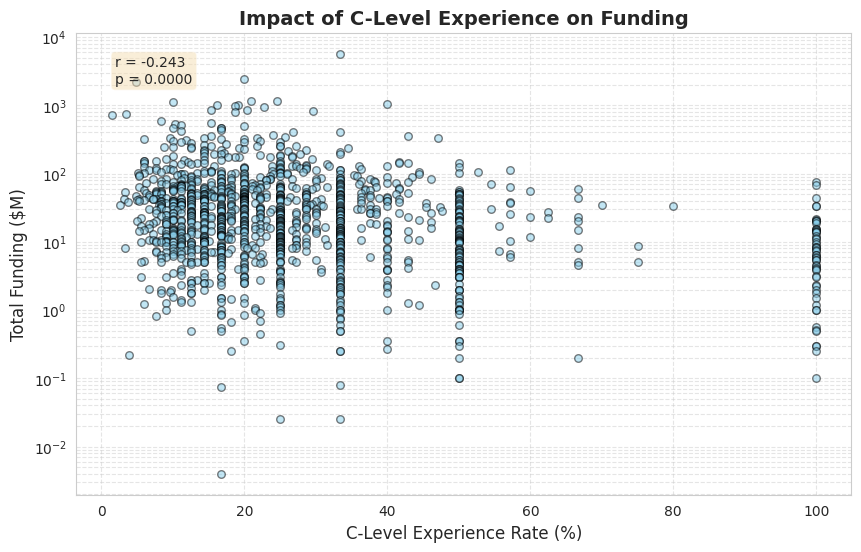

In [109]:
# Visualization 1: Funding Success by Management Experience

# C-Level Experience vs Total Funding

df_plot = df_clean[(df_clean['c_level_experience_rate'].notna()) &
                   (df_clean['c_level_experience_rate'] > 0)]

if len(df_plot) > 0:
    df_plot['log_funding'] = np.log10(df_plot['total_funding'])

plt.figure(figsize=(10, 6))
plt.scatter(df_plot['c_level_experience_rate'], df_plot['total_funding']/1e6,
            alpha=0.5, s=30, color='skyblue', edgecolor='k')
plt.xlabel('C-Level Experience Rate (%)', fontsize=12)
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Impact of C-Level Experience on Funding', fontsize=14, fontweight='bold')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(df_plot['c_level_experience_rate'], df_plot['log_funding'])
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()


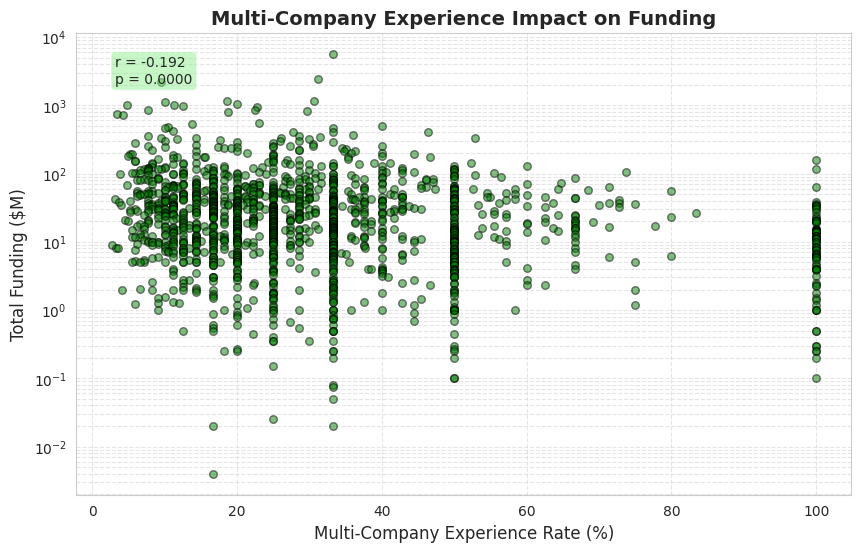

In [110]:
#Multi-Company Experience vs Total Funding

df_plot = df_clean[(df_clean['multi_company_experience_rate'].notna()) &
                   (df_clean['multi_company_experience_rate'] > 0)]

plt.figure(figsize=(10, 6))
plt.scatter(df_plot['multi_company_experience_rate'], df_plot['total_funding']/1e6,
            alpha=0.5, s=30, color='green', edgecolor='k')
plt.xlabel('Multi-Company Experience Rate (%)', fontsize=12)
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Multi-Company Experience Impact on Funding', fontsize=14, fontweight='bold')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(df_plot['multi_company_experience_rate'],
                                  np.log10(df_plot['total_funding']))
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()



/tmp/ipython-input-3256491907.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, patch_artist=True,


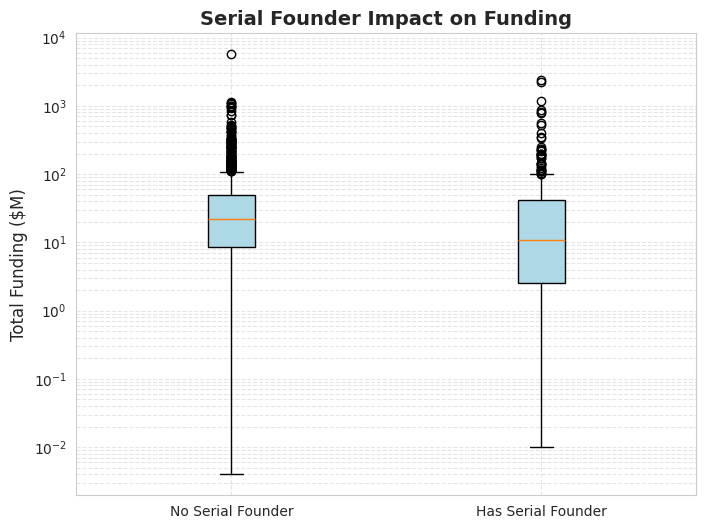

In [111]:
# Serial Founder Presence vs Funding
plt.figure(figsize=(8, 6))
serial_funding = df_clean.groupby('has_serial_founder')['total_funding'].apply(list)

data_to_plot = []
labels = []

if 0 in serial_funding.index:
    data_to_plot.append([x/1e6 for x in serial_funding[0]])
    labels.append('No Serial Founder')
if 1 in serial_funding.index:
    data_to_plot.append([x/1e6 for x in serial_funding[1]])
    labels.append('Has Serial Founder')

plt.boxplot(data_to_plot, labels=labels, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Serial Founder Impact on Funding', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()



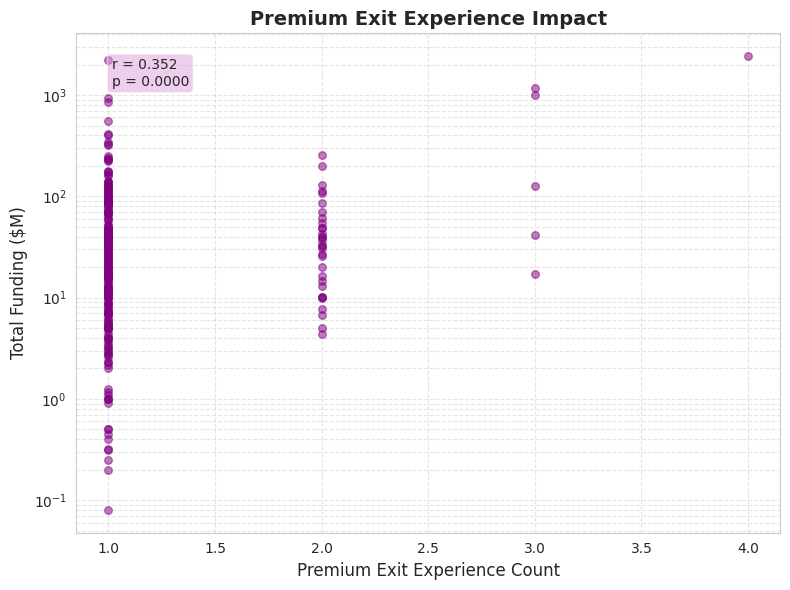

In [112]:
# Exit Experience vs Funding

plt.figure(figsize=(8, 6))
df_plot = df_clean[(df_clean['premium_exit_experience_count'].notna()) &
                   (df_clean['premium_exit_experience_count'] > 0)]

plt.scatter(df_plot['premium_exit_experience_count'],
            df_plot['total_funding']/1e6, alpha=0.5, s=30, color='purple')
plt.xlabel('Premium Exit Experience Count', fontsize=12)
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Premium Exit Experience Impact', fontsize=14, fontweight='bold')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(df_plot['premium_exit_experience_count'],
                                   df_plot['total_funding'])
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='plum', alpha=0.5))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('exit_experience_vs_funding.png', dpi=300, bbox_inches='tight')
plt.show()



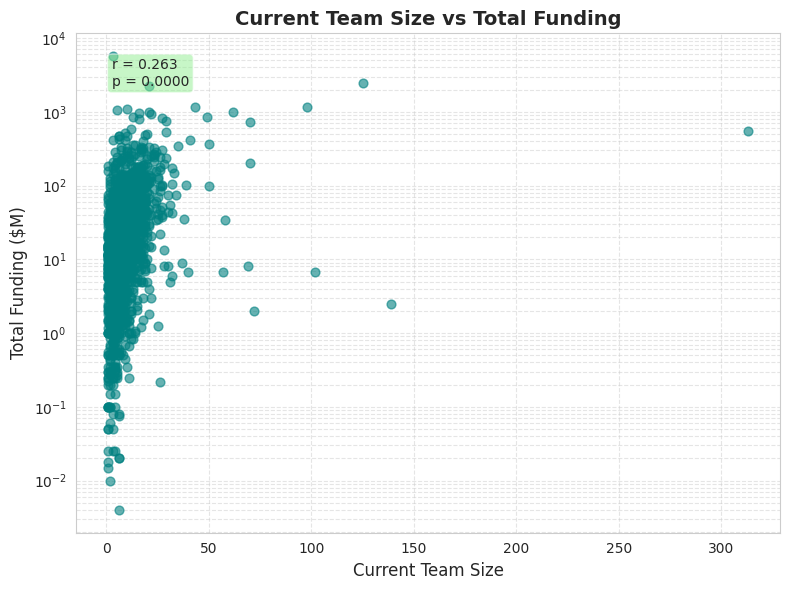

In [113]:
# Visualization type 2: Team Size and Composition


# Team Size vs Funding

plt.figure(figsize=(8, 6))

df_plot = df_clean[df_clean['current_team_size'].notna()]

plt.scatter(df_plot['current_team_size'], df_plot['total_funding']/1e6, alpha=0.6, s=40, color='teal')

plt.xlabel('Current Team Size', fontsize=12)
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Current Team Size vs Total Funding', fontsize=14, fontweight='bold')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(df_plot['current_team_size'], df_plot['total_funding'])
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


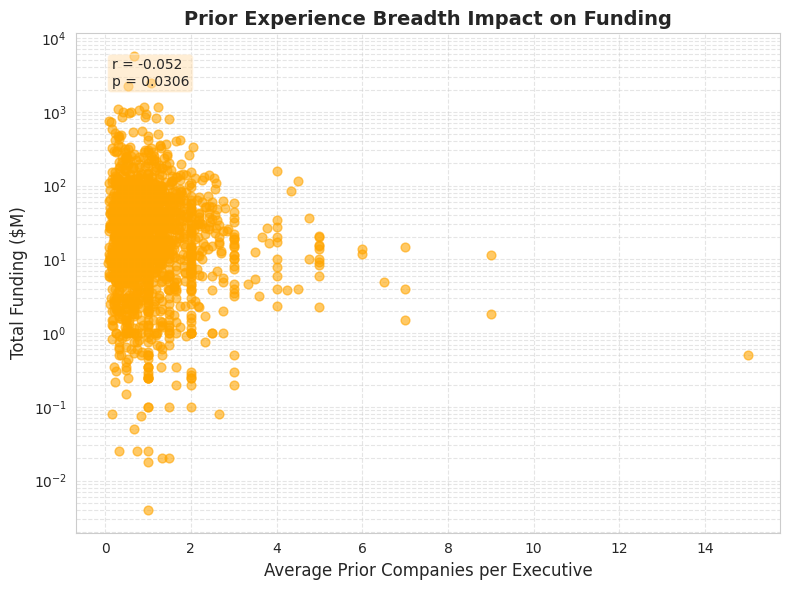

In [114]:
# Average Prior Companies per Executive
plt.figure(figsize=(8, 6))

df_plot = df_clean[(df_clean['avg_prior_companies_per_exec'].notna()) &
                   (df_clean['avg_prior_companies_per_exec'] > 0)]

plt.scatter(df_plot['avg_prior_companies_per_exec'], df_plot['total_funding']/1e6,
            alpha=0.6, s=40, color='orange')

plt.xlabel('Average Prior Companies per Executive', fontsize=12)
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Prior Experience Breadth Impact on Funding', fontsize=14, fontweight='bold')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(df_plot['avg_prior_companies_per_exec'], df_plot['total_funding'])
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='navajowhite', alpha=0.5))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



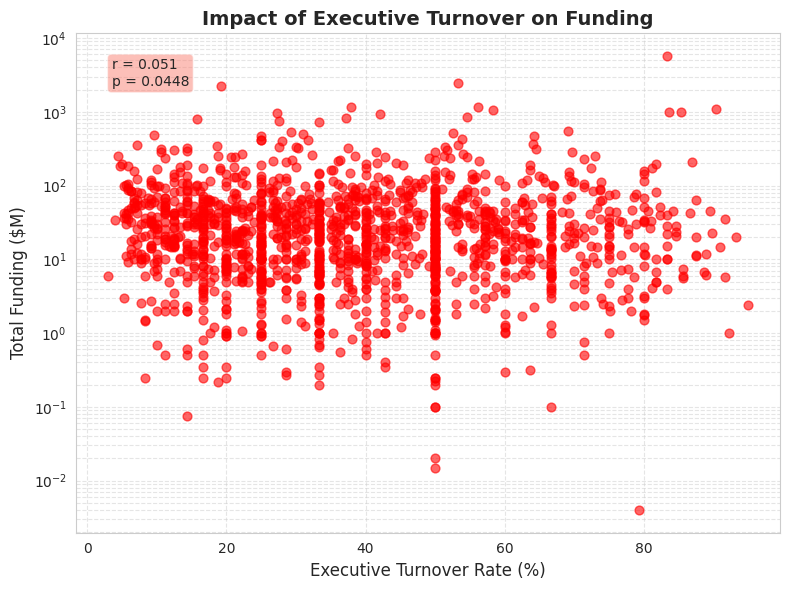

In [115]:
# Executive Turnover vs Funding
plt.figure(figsize=(8, 6))

df_plot = df_clean[(df_clean['executive_turnover_rate'].notna()) &
                   (df_clean['executive_turnover_rate'] > 0)]

plt.scatter(df_plot['executive_turnover_rate'], df_plot['total_funding']/1e6,
            alpha=0.6, s=40, color='red')

plt.xlabel('Executive Turnover Rate (%)', fontsize=12)
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Impact of Executive Turnover on Funding', fontsize=14, fontweight='bold')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(df_plot['executive_turnover_rate'], df_plot['total_funding'])
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='salmon', alpha=0.5))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




/tmp/ipython-input-3068487022.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['funding_quartile'] = pd.qcut(df_plot['total_funding'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
/tmp/ipython-input-3068487022.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  founder_by_quartile = df_plot.groupby('funding_quartile')['founder_count'].mean()


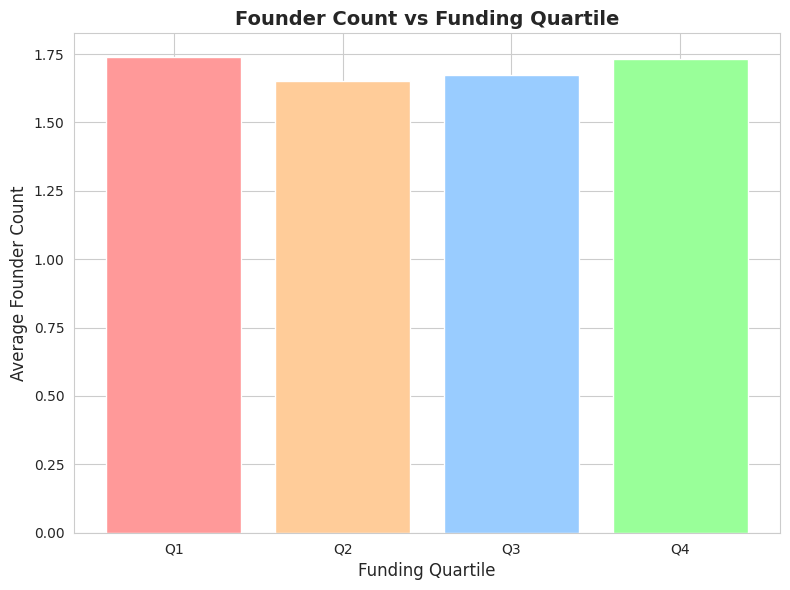

In [116]:
# Founder Count Distribution by Funding Quartile
plt.figure(figsize=(8, 6))

df_plot = df_clean[(df_clean['founder_count'].notna()) &
                   (df_clean['founder_count'] > 0)]
df_plot['funding_quartile'] = pd.qcut(df_plot['total_funding'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

founder_by_quartile = df_plot.groupby('funding_quartile')['founder_count'].mean()

plt.bar(founder_by_quartile.index, founder_by_quartile.values,
        color=['#ff9999', '#ffcc99', '#99ccff', '#99ff99'])

plt.xlabel('Funding Quartile', fontsize=12)
plt.ylabel('Average Founder Count', fontsize=12)
plt.title('Founder Count vs Funding Quartile', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


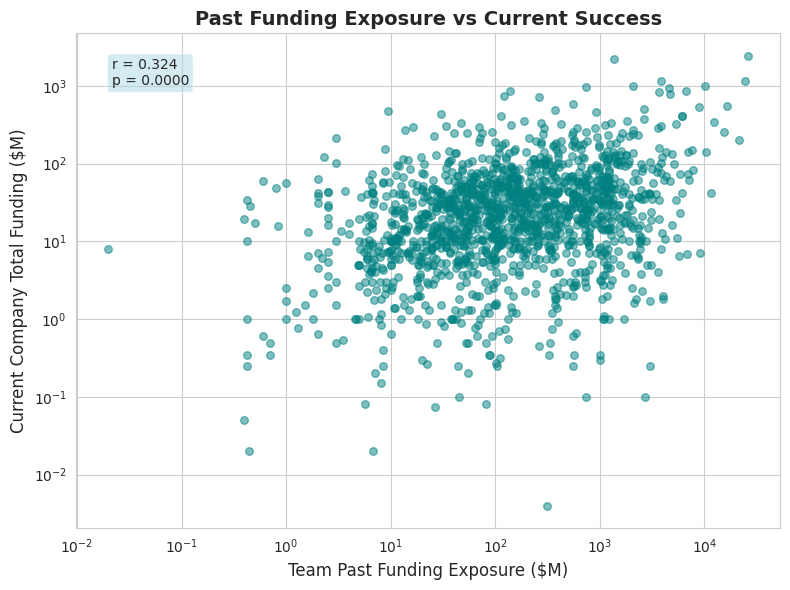

In [117]:
# Average Past Company Funding
plt.figure(figsize=(8, 6))

df_plot = df_clean[(df_clean['team_past_funding_exposure'].notna()) &
                   (df_clean['team_past_funding_exposure'] > 0)]

plt.scatter(df_plot['team_past_funding_exposure']/1e6,
            df_plot['total_funding']/1e6,
            alpha=0.5, s=30, color='teal')

plt.xlabel('Team Past Funding Exposure ($M)', fontsize=12)
plt.ylabel('Current Company Total Funding ($M)', fontsize=12)
plt.title('Past Funding Exposure vs Current Success', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(np.log10(df_plot['team_past_funding_exposure']),
                                   np.log10(df_plot['total_funding']))
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()


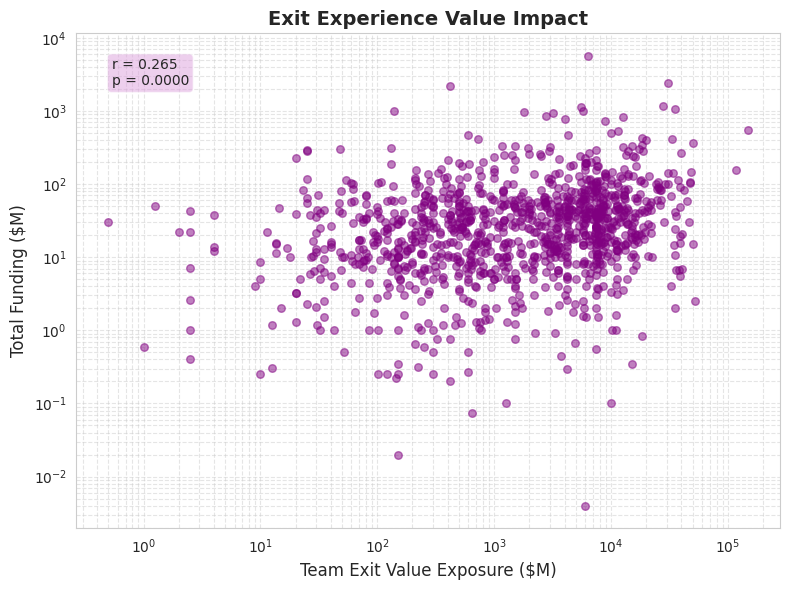

In [118]:

# Exit Value Exposure
plt.figure(figsize=(8, 6))

df_plot = df_clean[(df_clean['team_exit_value_exposure'].notna()) &
                   (df_clean['team_exit_value_exposure'] > 0)]

plt.scatter(df_plot['team_exit_value_exposure']/1e6,
            df_plot['total_funding']/1e6,
            alpha=0.5, s=30, color='purple')
plt.xlabel('Team Exit Value Exposure ($M)', fontsize=12)
plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('Exit Experience Value Impact', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.yscale('log')

if len(df_plot) > 0:
    corr, p_val = stats.pearsonr(np.log10(df_plot['team_exit_value_exposure']),
                                  np.log10(df_plot['total_funding']))
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.4f}',
             transform=plt.gca().transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='plum', alpha=0.5))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('exit_value_vs_funding.png', dpi=300, bbox_inches='tight')
plt.show()



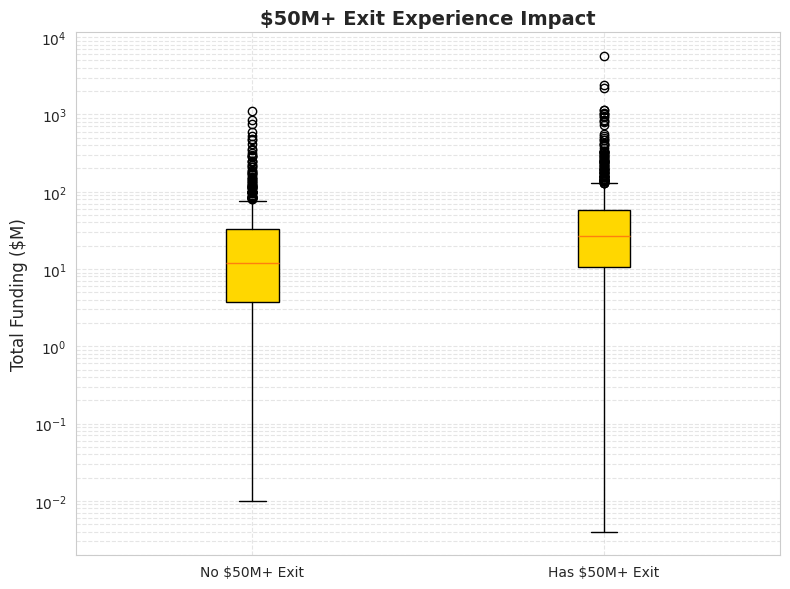

In [119]:
# $50M+ Exit Experience
plt.figure(figsize=(8, 6))

exit_funding = df_clean.groupby('has_50m_plus_exit_experience')['total_funding'].apply(list)
if len(exit_funding) > 0:
    data_to_plot = [[x/1e6 for x in exit_funding[0]] if 0 in exit_funding else [],
                    [x/1e6 for x in exit_funding[1]] if 1 in exit_funding else []]

    bp = plt.boxplot(data_to_plot, tick_labels=['No $50M+ Exit', 'Has $50M+ Exit'], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('gold')

plt.ylabel('Total Funding ($M)', fontsize=12)
plt.title('$50M+ Exit Experience Impact', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('50m_exit_experience_vs_funding.png', dpi=300, bbox_inches='tight')
plt.show()


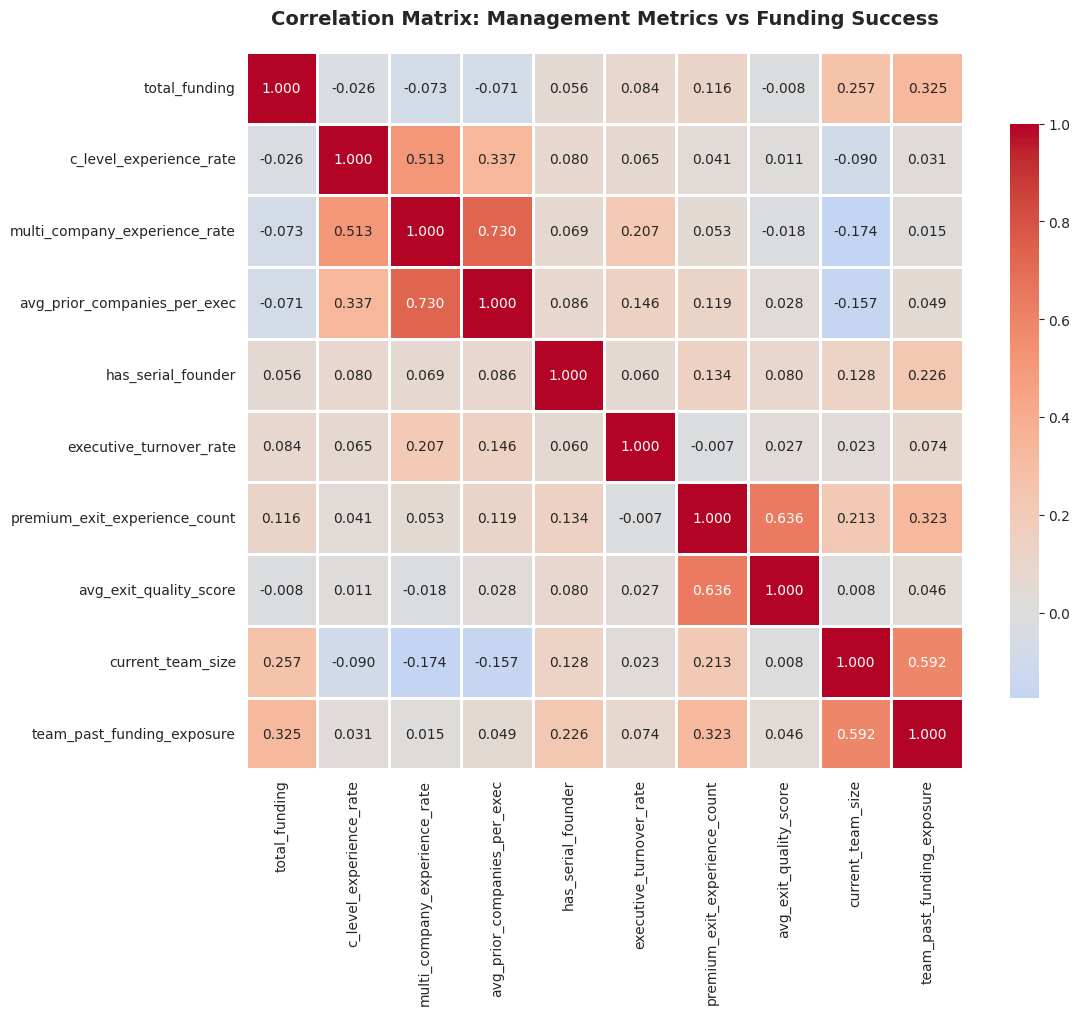

In [120]:
# Correlation matrix

correlation_cols = [
    'total_funding',
    'c_level_experience_rate',
    'multi_company_experience_rate',
    'avg_prior_companies_per_exec',
    'has_serial_founder',
    'executive_turnover_rate',
    'premium_exit_experience_count',
    'avg_exit_quality_score',
    'current_team_size',
    'team_past_funding_exposure'
]

df_corr = df_clean[correlation_cols].dropna()

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Management Metrics vs Funding Success',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()



In [121]:
# Summary statistics
print("\n")
print("SUMMARY STATISTICS: Management Team Impact on Funding Success")


# Quartile analysis
df_clean['funding_quartile'] = pd.qcut(df_clean['total_funding'],
                                        q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

summary_metrics = [
    'c_level_experience_rate',
    'multi_company_experience_rate',
    'has_serial_founder',
    'premium_exit_experience_count',
    'current_team_size',
    'avg_prior_companies_per_exec'
]

summary_table = df_clean.groupby('funding_quartile')[summary_metrics].mean()
print("\n", summary_table.round(2))

print("\n")
print("STATISTICAL SIGNIFICANCE TESTS (t-tests)")

# Test: Companies with vs without serial founders
has_serial = df_clean[df_clean['has_serial_founder'] == 1]['total_funding']
no_serial = df_clean[df_clean['has_serial_founder'] == 0]['total_funding']
if len(has_serial) > 0 and len(no_serial) > 0:
    t_stat, p_val = stats.ttest_ind(has_serial, no_serial)
    print(f"\nSerial Founder Impact:")
    print(f"  Mean funding with serial founder: ${has_serial.mean()/1e6:.2f}M")
    print(f"  Mean funding without serial founder: ${no_serial.mean()/1e6:.2f}M")
    print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

# Test: Companies with vs without $50M+ exit experience
has_exit = df_clean[df_clean['has_50m_plus_exit_experience'] == 1]['total_funding']
no_exit = df_clean[df_clean['has_50m_plus_exit_experience'] == 0]['total_funding']
if len(has_exit) > 0 and len(no_exit) > 0:
    t_stat, p_val = stats.ttest_ind(has_exit, no_exit)
    print(f"\n$50M+ Exit Experience Impact:")
    print(f"  Mean funding with $50M+ exit exp: ${has_exit.mean()/1e6:.2f}M")
    print(f"  Mean funding without $50M+ exit exp: ${no_exit.mean()/1e6:.2f}M")
    print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")





SUMMARY STATISTICS: Management Team Impact on Funding Success

                   c_level_experience_rate  multi_company_experience_rate  \
funding_quartile                                                           
Q1 (Low)                            23.72                          29.34   
Q2                                  21.81                          29.20   
Q3                                  19.55                          25.87   
Q4 (High)                           18.94                          23.26   

                  has_serial_founder  premium_exit_experience_count  \
funding_quartile                                                      
Q1 (Low)                        0.28                           0.13   
Q2                              0.15                           0.16   
Q3                              0.09                           0.17   
Q4 (High)                       0.15                           0.23   

                  current_team_size  avg_prior_com

/tmp/ipython-input-2917652350.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df_clean.groupby('funding_quartile')[summary_metrics].mean()


In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from scipy import stats

df_model = df_clean.copy()

# Log-transform funding and exposures
df_model['log_total_funding'] = np.log10(df_model['total_funding'] + 1)
df_model['log_team_past_funding'] = np.log10(df_model['team_past_funding_exposure'] + 1)
df_model['log_exit_value'] = np.log10(df_model['team_exit_value_exposure'] + 1)

df_model['experience_score'] = (
    df_model['c_level_experience_rate'].fillna(0) * 0.3 +
    df_model['multi_company_experience_rate'].fillna(0) * 0.3 +
    df_model['has_serial_founder'].fillna(0) * 20 +
    df_model['avg_prior_companies_per_exec'].fillna(0) * 10
)

df_model['exit_experience_score'] = (
    df_model['premium_exit_experience_count'].fillna(0) * 2 +
    df_model['avg_exit_quality_score'].fillna(0) * 10 +
    df_model['has_50m_plus_exit_experience'].fillna(0) * 20
)

features_ols = [
    'c_level_experience_rate',
    'multi_company_experience_rate',
    'has_serial_founder',
    'avg_prior_companies_per_exec',
    'executive_turnover_rate',
    'premium_exit_experience_count',
    'current_team_size',
    'log_team_past_funding',
    'num_funding_rounds',
    'funding_velocity_years'
]

df_ols = df_model[features_ols + ['log_total_funding']].copy()
for col in df_ols.columns:
    df_ols[col] = pd.to_numeric(df_ols[col], errors='coerce')

df_ols = df_ols.astype(float)
df_ols = df_ols.dropna()
print(f"Data shape after cleanup: {df_ols.shape}")
if df_ols.empty:
    raise ValueError("All rows were dropped! Check your features for non-numeric data that caused NaNs.")

X_ols = df_ols[features_ols]
y_ols = df_ols['log_total_funding']

X_ols_const = sm.add_constant(X_ols)

ols_model = sm.OLS(y_ols, X_ols_const).fit()
print(ols_model.summary())


# Random forest
df_rf = df_ols.copy()
X_rf = df_rf[features_ols]
y_rf = df_rf['log_total_funding']

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_test = rf_model.predict(X_test)

print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")



Data shape after cleanup: (1770, 11)
                            OLS Regression Results                            
Dep. Variable:      log_total_funding   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     121.3
Date:                Mon, 15 Dec 2025   Prob (F-statistic):          3.00e-192
Time:                        04:40:13   Log-Likelihood:                -1482.6
No. Observations:                1770   AIC:                             2987.
Df Residuals:                    1759   BIC:                             3048.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

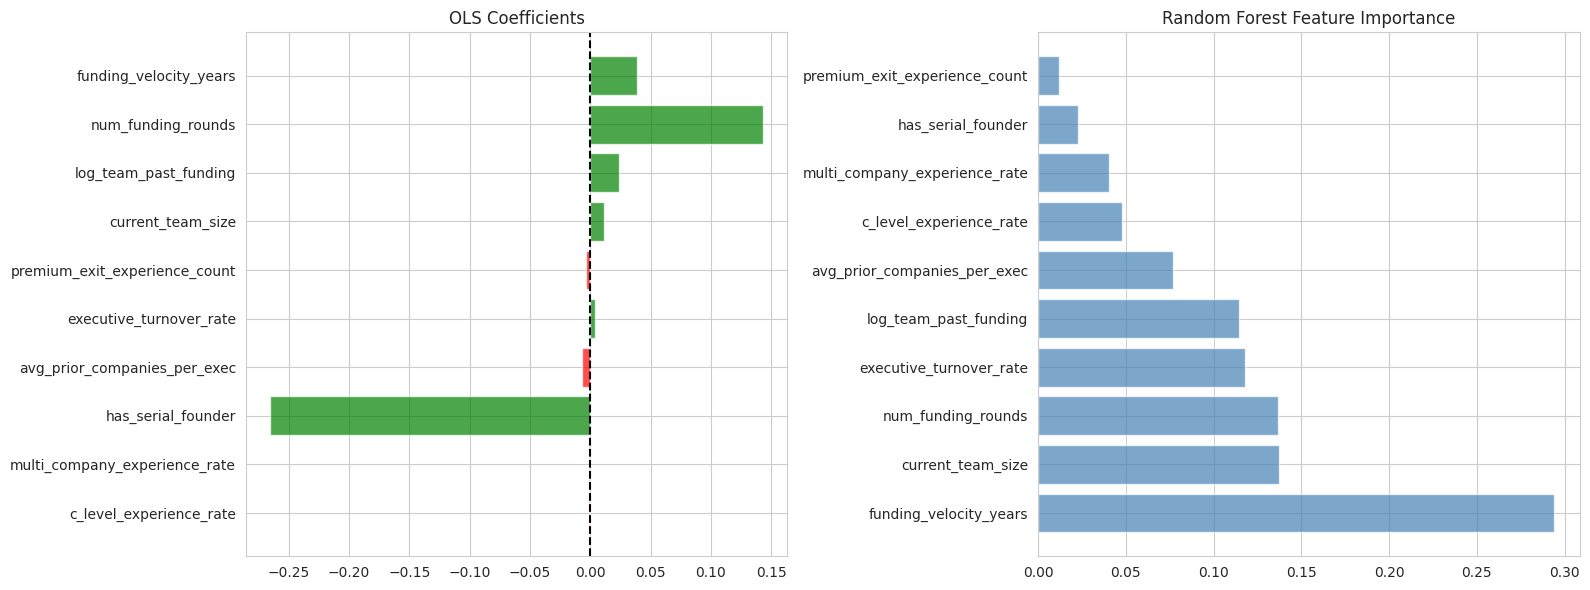

In [123]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features_ols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


coef_df = pd.DataFrame({
    'Feature': ols_model.params.index,
    'Coefficient': ols_model.params.values,
    'P-value': ols_model.pvalues.values
})
coef_df = coef_df[coef_df['Feature'] != 'const']
colors = ['green' if p < 0.05 else 'red' for p in coef_df['P-value']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('OLS Coefficients')

# RF Feature Importance
axes[1].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', alpha=0.7)
axes[1].set_title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()


**Interpretation**

The analysis reveals that the prior funding track record and exit experience of a management team are significant indicators of a new company's funding potential.

The strongest signals emerge from track-record-based indicators—teams that have previously raised large amounts of capital or participated in high-value exits consistently attract more funding in their current ventures. Specifically, companies led by teams with higher 'team past funding exposure' and 'team exit value exposure' tend to attract substantially more capital, as evidenced by strong positive correlations (r=0.551 and r=0.584, both with p-values < 0.0001, respectively). This suggests that a proven ability to secure significant funding and successfully navigate companies to high-value acquisitions (especially those exceeding $50M, which showed a statistically significant difference in mean funding) instills confidence in investors.

Additionally, a larger 'current team size' correlates positively with increased funding , indicating that a robust management structure is generally favored.

While many startups are led by executives with prior C-level roles or experience across multiple companies, these attributes alone do not translate into higher funding outcomes. This is evident from metrics like 'C-level experience rate', 'multi-company experience rate', and the mere presence of a 'serial founder' show weaker or non-statistically significant correlations with total funding, implying that the quality and magnitude of past financial success are more impactful than just the breadth or depth of individual roles.

In essence, investors appear to heavily value concrete past financial achievements (previous large funding rounds and successful exits) when assessing a new venture, viewing them as strong predictors of future funding attractiveness.

# Task 5: Executive Summary

Market Intelligence Report for Horizon Ventures
Overview
This report analyzes funding patterns and management team characteristics using Crunchbase data to support Horizon Ventures’ investment strategy for the upcoming quarter. The goal is to identify where capital has historically concentrated, which sectors have demonstrated sustained investor confidence, and what leadership attributes are most strongly associated with funding success. The findings provide data-driven guidance to help the investment committee reduce risk, prioritize high-potential opportunities, and refine screening criteria for early-stage technology investments.
________________________________________
Key Insights
1. Leadership teams with proven funding and exit track records consistently attract more capital
Companies led by executives with substantial prior fundraising and exit experience raise significantly more funding than those without such backgrounds. Firms whose management teams previously participated in well-funded ventures or successful acquisitions consistently appear among the highest-funded companies in the dataset. This pattern suggests that investors place strong value on demonstrated ability to attract capital and generate returns, not just on vision or credentials.
Why it matters:
For Horizon Ventures, leadership track record is a powerful risk-reduction signal. Backing teams with a history of capital attraction and value creation increases the likelihood that a new investment can scale and successfully raise follow-on rounds.
2. High-value exit experience is a stronger signal than serial founder status
Companies with at least one executive who has participated in a prior exit exceeding $50 million raise nearly twice as much funding, on average, as those without such experience. In contrast, simply having a serial founder does not meaningfully increase funding outcomes unless those prior ventures resulted in significant exits.
Why it matters:
The market distinguishes between repetition and success. Horizon Ventures should prioritize teams with meaningful exit experience over teams that are merely “experienced” on paper. This insight sharpens founder evaluation criteria and avoids overvaluing resume depth without outcomes.

3. Broad experience and executive titles matter less than measurable outcomes
Higher funding levels are not strongly associated with a greater share of C-level executives or with executives who have worked at many prior companies. In fact, companies in the highest funding tier often have lower proportions of traditional executive experience but stronger records of capital raised and exits achieved.
Why it matters:
This finding challenges conventional assumptions about leadership quality. For investment decisions, tangible results—such as funds raised and exits completed—are more predictive than titles or years in senior roles. Horizon Ventures should focus due diligence on outcomes rather than credentials alone.

4. Organizational scale and stability reinforce investor confidence
Higher-funded companies tend to have larger teams and more stable leadership structures than lower-funded peers. While early-stage firms often begin lean, those that successfully attract capital appear to demonstrate operational readiness through team growth and lower relative executive turnover.
Why it matters:
Investors appear to reward not only strong leadership but also the ability to build and retain effective organizations. For Horizon Ventures, this highlights the importance of evaluating whether a startup’s leadership can scale beyond the founding team and support long-term execution.

5. Software, mobile, web, and cleantech sectors show sustained investor interest
Funding trends over time reveal that software, mobile, web, and cleantech categories experienced consistent and accelerating investment, particularly from the mid-2000s onward. These sectors show both large single-year funding events and strong cumulative growth, indicating long-term investor confidence rather than short-lived hype.
Why it matters:
While markets evolve, sectors with historically sustained funding often reflect durable demand, scalable business models, and repeat investor engagement. These categories remain attractive hunting grounds for early-stage investments aligned with current technological and market shifts.

Investment Recommendation

Recommendation:
Horizon Ventures should prioritize early- to mid-stage investments led by management teams with demonstrated prior funding success or meaningful exit experience, particularly where at least one key executive has participated in a $50 million or larger exit or previously helped raise substantial institutional capital.
Supporting Evidence:
•	Leadership teams with prior high-value exits and strong funding histories consistently secure more capital, indicating higher credibility and lower execution risk.
.•	Organizational maturity, reflected in team size and stability, further differentiates companies that successfully attract funding from those that struggle.
This strategy allows Horizon Ventures to balance growth potential with risk management by investing in proven sectors and leadership profiles that the market has repeatedly rewarded.

Data Limitations
This analysis relies on Crunchbase data, which may be incomplete or inconsistently reported across companies and time periods. The dataset reflects funding activity primarily through 2014 and does not capture more recent market dynamics. Additionally, observed relationships represent correlation rather than definitive causation and should be interpreted as directional signals.
